<a href="https://colab.research.google.com/github/animalwor1d/AFR-Project/blob/main/%E2%80%9CLLaVA_two_step_fine_tuning%E2%80%9D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://docs.unsloth.ai/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth on your own computer, follow the installation instructions on our Github page [here](https://docs.unsloth.ai/get-started/installing-+-updating).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & [how to save it](#Save)


### Installation

In [ ]:
%%capture
import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:

    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1" huggingface_hub hf_transfer
    !pip install --no-deps unsloth

### Unsloth

In [ ]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.7.11: Fast Llava patching. Transformers: 4.54.1.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.30G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/177 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

**[NEW]** We also support finetuning ONLY the vision part of the model, or ONLY the language part. Or you can select both! You can also select to finetune the attention or the MLP layers!

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = True,  # support rank stabilized LoRA
    loftq_config = {}, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Making `base_model.model.model.vision_tower.vision_model` require gradients


In [ ]:
from unsloth import FastVisionModel

# ================== LoRA injection (get_peft_model variant) ==================
# If you only want to tune the language side and leave vision untouched:
#   set finetune_vision_layers=False
# Example below shows inserting LoRA into language, vision, attention and MLP.
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,   # Insert LoRA into image projection layers
    finetune_language_layers   = True,   # Insert LoRA on the text / language side
    finetune_attention_modules = True,   # Apply to Q, K, V, O linear projections
    finetune_mlp_modules       = True,   # Apply to the two linear layers in FFN

    # -------- LoRA hyperparams --------
    r            = 16,     # Low-rank dimension (e.g. 32 worked well for 51 few-shot examples)
    lora_alpha   = 16,     # Scaling factor; recommended to match rank
    lora_dropout = 0,      # Dropout for regularization; 0.2 is often more stable in few-shot
    bias         = "none", # Bias handling (usually leave as-is)
    random_state = 3407,
    use_rslora   = True,   # Set True for rank-stable LoRA
    loftq_config = {},     # LoftQ quantization config (optional)
    # target_modules = "all-linear",   # Default is fine; provide a list to restrict (e.g. attention-only)
)

# Optional: print how many target modules have LoRA applied
print("LoRA layers injected:", len(model.peft_config["default"].target_modules))


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<a name="Data"></a>
### Data Prep
We'll be using a sampled version of the ROCO radiography dataset. You can access the dataset [here](https://huggingface.co/datasets/unsloth/Radiology_mini). The full dataset is [here](https://huggingface.co/datasets/eltorio/ROCOv2-radiology).

The dataset includes X-rays, CT scans and ultrasounds showcasing medical conditions and diseases. Each image has a caption written by experts describing it. The goal is to finetune a VLM to make it a useful analysis tool for medical professionals.


In [ ]:
from datasets import load_from_disk  # load a saved dataset

train_ds = load_from_disk("/content/drive/MyDrive/Colab Notebooks/train_vlm-twostep")  # training setA
val_ds   = load_from_disk("/content/drive/MyDrive/Colab Notebooks/val_vlm-twostep")    # validation setA
test_ds  = load_from_disk("/content/drive/MyDrive/Colab Notebooks/test_vlm-twostep")   # test setA
contrast150_vlm = load_from_disk("/content/drive/MyDrive/Colab Notebooks/contrast150_vlm") # 15 additional test models
train_vlm_contrast1000 = load_from_disk("/content/drive/MyDrive/Colab Notebooks/train_vlm_contrast1000-twostep") #datasetB
test_vlm_contrast1000 = load_from_disk("/content/drive/MyDrive/Colab Notebooks/test_vlm_contrast1000-twostep") #datasetB

In [ ]:
train_ds

Dataset({
    features: ['images', 'messages'],
    num_rows: 1800
})

Let's take a look at the dataset, and check what the 1st example shows:

In [ ]:
# images: list containing either image URLs or PIL.Image objects (shows the first sample)
train_ds[0]["images"]

[<PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>]

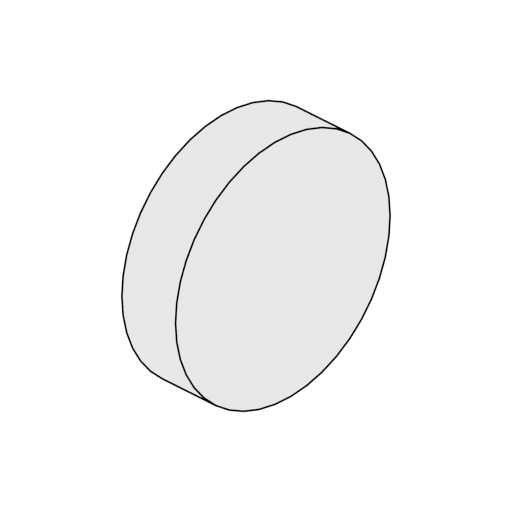

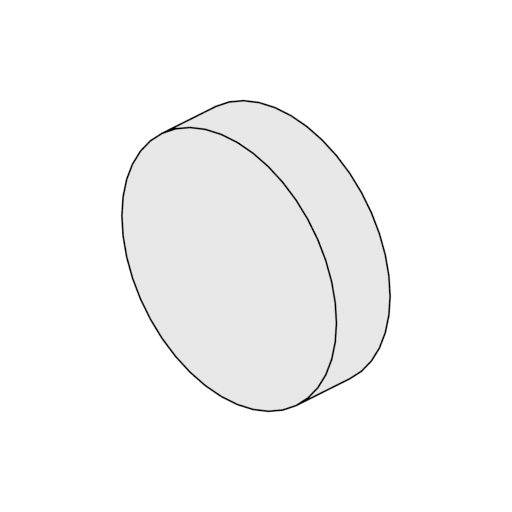

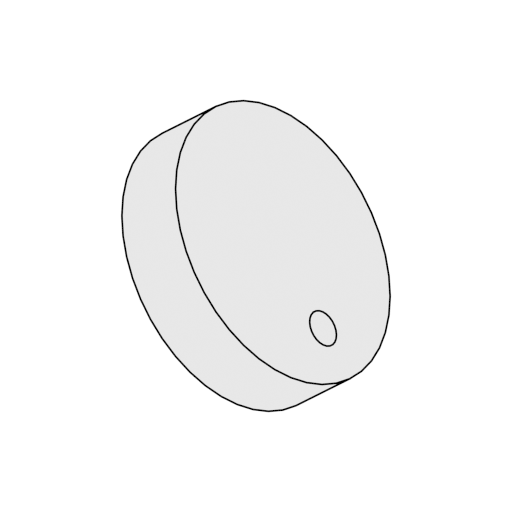

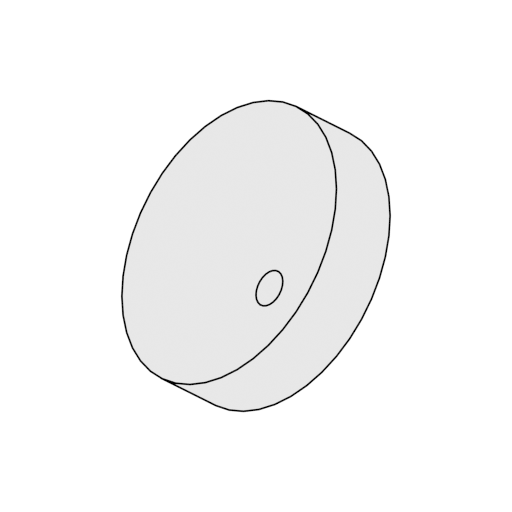

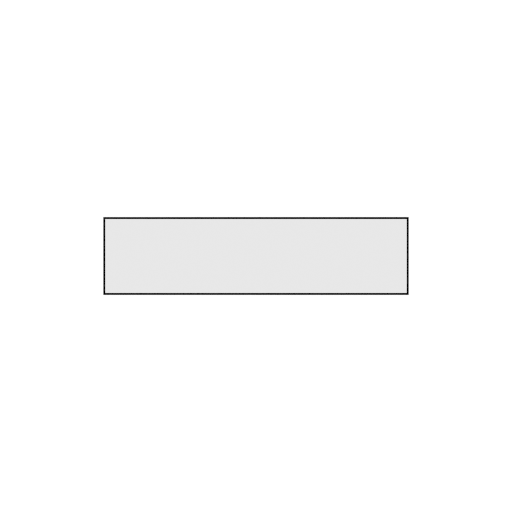

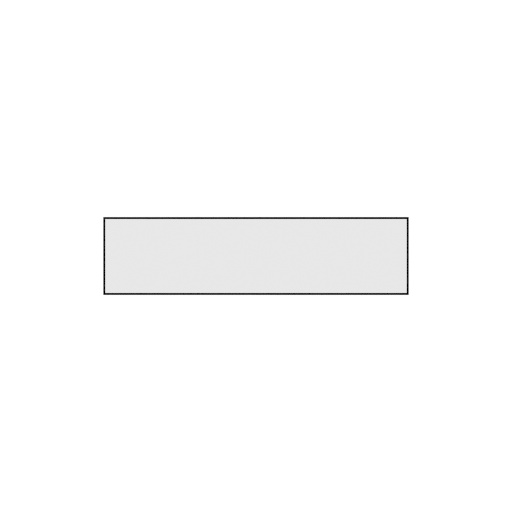

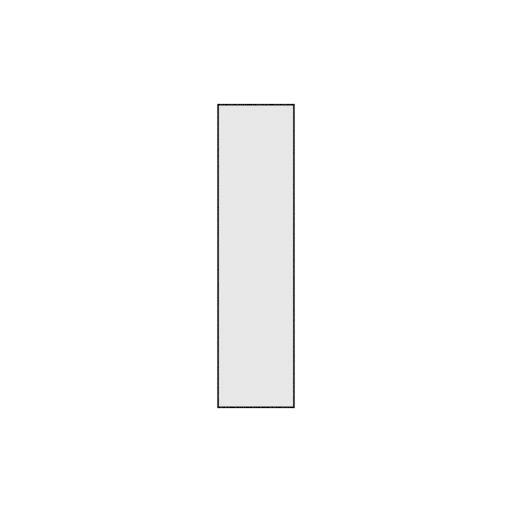

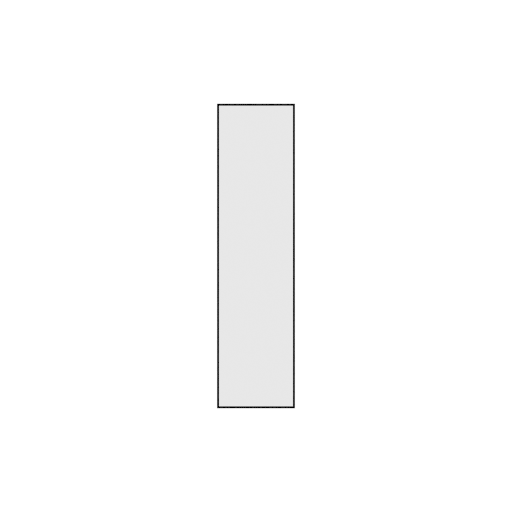

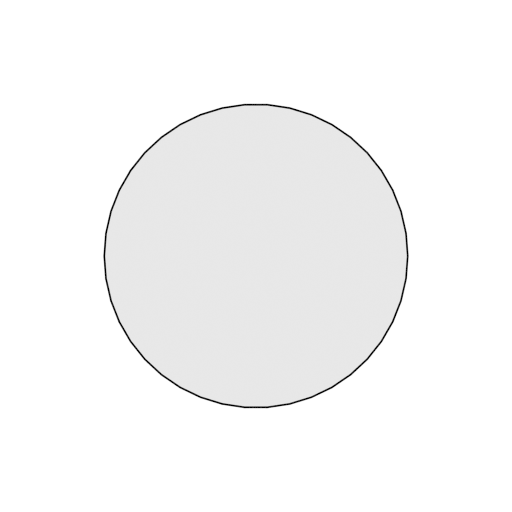

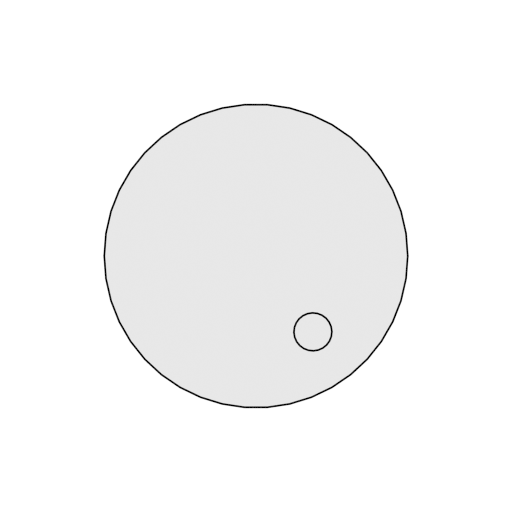

In [ ]:
from IPython.display import display

# Get the ten images from the first sample (list of URLs or PIL.Image objects)
imgs = train_ds[0]["images"]

# Display each image in the notebook (renders to the output cell)
for img in imgs:
    display(img)


In [ ]:
# Show the first record (dict) — contains 'images' (list) and 'messages' (list)
train_ds[0]

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>],
 'messages': [{'content': [{'text': 'You will receive TEN fixed‐view images of a 3D‐CAD part.  \nYour task is to output ONLY the following JSON with exactly these six integer fields:\n- Hole_Through_count\n- Hole_Blind_count\n- Pocket_Opened_count\n- Pocket_Closed_count\n- Corner_Fillet_count\n- Corner_Chamfer_count\n====================

In [ ]:
sample = contrast150_vlm[0]
print(sample.keys())
# dict_keys(['images', 'messages'])

imgs = sample['images']
print(type(imgs), len(imgs))
# <class 'list'> 10

first_img = imgs[0]
print(type(first_img))
# <class 'PIL.Image.Image'>


dict_keys(['images', 'messages'])
<class 'list'> 10
<class 'PIL.PngImagePlugin.PngImageFile'>


In [ ]:

print(train_vlm_contrast1000["part_id"][:51])


[2, 3, 4, 7, 8, 11, 15, 19, 21, 23, 24, 26, 28, 29, 30, 31, 33, 2, 3, 4, 7, 8, 11, 15, 19, 21, 23, 24, 26, 28, 29, 30, 31, 33, 2, 3, 4, 7, 8, 11, 15, 19, 21, 23, 24, 26, 29, 30, 31, 32, 34]


Before we do any finetuning, maybe the vision model already knows how to analyse the images? Let's check if this is the case!

In [ ]:
print(test_vlm_contrast1000["part_id"][:51])

[1, 5, 6, 9, 10, 12, 13, 14, 16, 17, 18, 20, 22, 25, 27, 32, 1, 5, 6, 9, 10, 12, 13, 14, 16, 17, 18, 20, 22, 25, 27, 28, 33, 1, 5, 6, 9, 10, 12, 13, 14, 16, 17, 18, 20, 22, 25, 27, 32]


# Stitched image input format

In [ ]:
from datasets import Dataset
from PIL import Image

# ---------- Stitch 10 images into one grid ----------
def stitch_images(img_list, cols=5, rows=2):
    """Stitch img_list (cols x rows) into a single grid image, preserving original resolution."""
    assert len(img_list) == cols * rows, "需要刚好 %d 张图" % (cols * rows)
    w, h = img_list[0].size        # assume each image has the same size (e.g. 512x512)
    grid = Image.new("RGB", (w * cols, h * rows))
    for idx, img in enumerate(img_list):
        x = (idx % cols) * w
        y = (idx // cols) * h
        grid.paste(img, (x, y))
    return grid    # returns grid image (e.g. 2560x1024 for a 5x2 layout)

import os
import json
from typing import List, Dict
from PIL import Image
import torch
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from tqdm import tqdm

# Mute transformers logs and clear CUDA memory
logging.set_verbosity_error()
torch.cuda.empty_cache()

# =========================================================
# 1) Feature JSON & output schema
# =========================================================

manufacturing_features_names = '''[
  {
    "name": "Through Hole"
  },
  {
    "name": "Blind Hole"
  },
  {
    "name": "Opened Pocket"
  },
  {
    "name": "Closed Pocket"
  },
  {
    "name": "Chamfer"
  },
  {
    "name": "Fillet"
  }
]'''


def transform_groundtruth(
    flat_gt_json: str,
    manufacturing_features_names: str
) -> str:
    """
    Convert a flat ground-truth JSON string into the `identified_features` structure.
    Output matches the prompt's Example output (4-space indent).
    Mapping:
      - "Through Hole"  -> "Hole_Through_count"
      - "Blind Hole"    -> "Hole_Blind_count"
      - "Opened Pocket" -> "Pocket_Opened_count"
      - "Closed Pocket" -> "Pocket_Closed_count"
      - "Chamfer"/"Fillet" -> "Corner_<Name>_count"
    Returns: pretty-printed JSON string.
    """
    flat_gt = json.loads(flat_gt_json)
    features_list = json.loads(manufacturing_features_names)

    new_gt = {"identified_features": []}
    for feat in features_list:
        name = feat["name"]              # e.g. "Through Hole"
        parts = name.split()             # e.g. ["Through","Hole"]

        # Decide feature class by the last word and build the corresponding flat key
        last = parts[-1]
        if last == "Hole":
            # Through Hole / Blind Hole
            flat_key = f"Hole_{parts[0]}_count"
        elif last == "Pocket":
            # Opened Pocket / Closed Pocket
            flat_key = f"Pocket_{parts[0]}_count"
        else:
            # Chamfer or Fillet -> prefix with Corner_
            flat_key = f"Corner_{name}_count"

        # Read value from flat JSON, default to 0 if missing
        count = flat_gt.get(flat_key, 0)
        exists = bool(count > 0)

        new_gt["identified_features"].append({
            "feature_name": name,
            "exists": exists,
            "quantity": count
        })

    return json.dumps(new_gt, indent=4)


# =========================================================
# 2) INST-format Prompt
# =========================================================

prompt_feature_recognition_3 = f"""[INST]

You are provided with an image containing multiple views of a 3D CAD model taken from different viewing angles.
Your task is to identify and describe the manufacturing features present in this image.
Use the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:

'''{manufacturing_features_names}'''

Instructions:
1. **Go through the COMPLETE list of manufacturing features one by one.**
2. **Think about whether each particular feature exists in the given image.**
3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**
4. Examine **each views** of the part to identify all features. Different angles may reveal features not visible in other views.
5. For each feature, provide **Quantity:** The number of such features present in the image (e.g., if there are two "Through Holes", then quantity is 2). \
    This should be a numerical integer (0, 1, 2, ...).

Return the results in the following JSON format, strictly adhering to the specified structure, \
**Do not include any other content, including any punctuation around the text.**:

Example output:
{{
    "identified_features": [
        {{

            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        }},
        {{
            "feature_name": "Chamfer",
            "exists": true,
            "quantity": 1
        }},
        {{
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }}
    ]
}}
[/INST]"""

# =========================================================
# 3) Conversation conversion helper
# =========================================================
IMAGE_TOKEN = "<image>"

def convert_to_conversation(sample: Dict) -> Dict:
    # 1) Stitch ten images into a single grid image
    grid_img = stitch_images(sample["images"], cols=5, rows=2)

    # 2) Build the user message: text prompt followed by the image
    user_content = [
        {"type": "text", "text": prompt_feature_recognition_3},
        {"type": "image", "image": grid_img}
    ]
    user_msg = {"role": "user", "content": user_content}

    # 3) Build the assistant message: pretty-print the last flat JSON as identified_features
    raw_flat = sample["messages"][-1]["content"][0]["text"].strip()
    pretty_json = transform_groundtruth(raw_flat, manufacturing_features_names)
    assistant_msg = {
        "role": "assistant",
        "content": [{"type": "text", "text": pretty_json}]
    }

    return {"messages": [user_msg, assistant_msg]}


# DatasetA format conversion

In [ ]:
converted_list = [convert_to_conversation(sample) for sample in train_ds]

In [ ]:
val_dataset = [convert_to_conversation(sample) for sample in val_ds]

In [ ]:
test_dataset = [convert_to_conversation(sample) for sample in test_ds]

# Separately input images

In [ ]:
from datasets import Dataset
from PIL import Image
import os
import json
from typing import List, Dict
from PIL import Image
import torch
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from tqdm import tqdm

# Mute transformers logs and clear CUDA cache
logging.set_verbosity_error()
torch.cuda.empty_cache()

# =========================================================
# 1) Feature JSON & output schema
# =========================================================

manufacturing_features_names = '''[
  {
    "name": "Through Hole"
  },
  {
    "name": "Blind Hole"
  },
  {
    "name": "Opened Pocket"
  },
  {
    "name": "Closed Pocket"
  },
  {
    "name": "Chamfer"
  },
  {
    "name": "Fillet"
  }
]'''


def transform_groundtruth(
    flat_gt_json: str,
    manufacturing_features_names: str
) -> str:
    """
    Convert a flat ground-truth JSON string into the `identified_features` structure.
    Output matches the prompt's Example output (4-space indent).

    Mapping:
      - "Through Hole"  -> "Hole_Through_count"
      - "Blind Hole"    -> "Hole_Blind_count"
      - "Opened Pocket" -> "Pocket_Opened_count"
      - "Closed Pocket" -> "Pocket_Closed_count"
      - "Chamfer"/"Fillet" -> "Corner_<Name>_count"

    Returns:
        pretty-printed JSON string matching the prompt schema.
    """
    flat_gt = json.loads(flat_gt_json)
    features_list = json.loads(manufacturing_features_names)

    new_gt = {"identified_features": []}
    for feat in features_list:
        name = feat["name"]              # e.g. "Through Hole"
        parts = name.split()             # e.g. ["Through","Hole"]

        # Decide feature class by the last word and build the corresponding flat key
        last = parts[-1]
        if last == "Hole":
            # Through Hole / Blind Hole
            flat_key = f"Hole_{parts[0]}_count"
        elif last == "Pocket":
            # Opened Pocket / Closed Pocket
            flat_key = f"Pocket_{parts[0]}_count"
        else:
            # Chamfer or Fillet -> prefix with Corner_
            flat_key = f"Corner_{name}_count"

        # Read value from flat JSON, default to 0 if missing
        count = flat_gt.get(flat_key, 0)
        exists = bool(count > 0)

        new_gt["identified_features"].append({
            "feature_name": name,
            "exists": exists,
            "quantity": count
        })

    return json.dumps(new_gt, indent=4)

# =========================================================
# 2) INST-format Prompt
# =========================================================

prompt_feature_recognition_3 = f"""[INST]

You are provided with multiple images of a 3D CAD model taken from different viewing angles.
Your task is to identify and describe the manufacturing features present in this image.
Use the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:

'''{manufacturing_features_names}'''

Instructions:
1. **Go through the COMPLETE list of manufacturing features one by one.**
2. **Think about whether each particular feature exists in the given image.**
3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**
4. Examine **each views** of the part to identify all features. Different angles may reveal features not visible in other views.
5. For each feature, provide **Quantity:** The number of such features present in the image (e.g., if there are two "Through Holes", then quantity is 2). \
    This should be a numerical integer (0, 1, 2, ...).

Return the results in the following JSON format, strictly adhering to the specified structure, \
**Do not include any other content, including any punctuation around the text.**:

Example output:
{{
    "identified_features": [
        {{

            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        }},
        {{
            "feature_name": "Chamfer",
            "exists": true,
            "quantity": 1
        }},
        {{
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }}
    ]
}}
[/INST]"""

# =========================================================
# 3) Conversation conversion helper
# =========================================================
IMAGE_TOKEN = "<image>"

def convert_to_conversation(sample: Dict) -> Dict:
    imgs: List[Image.Image] = sample["images"]
    assert imgs, "sample must contain at least one image"

    # 1) The prompt text itself contains no <image> token
    content = [{"type": "text", "text": prompt_feature_recognition_3}]

    # 2) Append image elements only — do NOT insert the literal "<image>" text
    for img in imgs:
        content.append({"type": "image", "image": img})

    user_msg = {"role": "user", "content": content}

    # 3) Build assistant message: convert the last flat JSON into the pretty schema
    raw_flat = sample["messages"][-1]["content"][0]["text"].strip()
    pretty_json = transform_groundtruth(raw_flat, manufacturing_features_names)

    assistant_msg = {
        "role": "assistant",
        "content": [{"type": "text", "text": pretty_json}],
    }
    return {"messages": [user_msg, assistant_msg]}


# DatasetB format conversion

In [ ]:
train_contrast1000_dataset = [convert_to_conversation(sample) for sample in train_vlm_contrast1000]

In [ ]:
test_contrast1000_dataset = [convert_to_conversation(sample) for sample in test_vlm_contrast1000]

# Stitched image input format - for 15 additional test models

In [ ]:
from datasets import Dataset
from PIL import Image

# ---------- Stitch 10 images into a single large image ----------
def stitch_images(img_list, cols=5, rows=2):
    """Stitch img_list[0..9] into a grid of size cols×rows, preserving the original resolution."""
    assert len(img_list) == cols * rows, "Exactly %d images are required" % (cols * rows)
    w, h = img_list[0].size        # Assume each image is 512×512
    grid = Image.new("RGB", (w * cols, h * rows))
    for idx, img in enumerate(img_list):
        x = (idx % cols) * w
        y = (idx // cols) * h
        grid.paste(img, (x, y))
    return grid    # Output is 2560×1024

import os
import json
from typing import List, Dict
from PIL import Image
import torch
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from tqdm import tqdm

# ----- Silence logs & clear GPU cache -----
logging.set_verbosity_error()
torch.cuda.empty_cache()

# =========================================================
# 1) Feature JSON (preserved)
# =========================================================

manufacturing_features_names = '''[
  {
    "name": "Through Hole"
  },
  {
    "name": "Blind Hole"
  },
  {
    "name": "Opened Pocket"
  },
  {
    "name": "Closed Pocket"
  },
  {
    "name": "Chamfer"
  },
  {
    "name": "Fillet"
  }
]'''

# =========================================================
# 2) INST-format Prompt (note double curly braces escaping)
# =========================================================

prompt_feature_recognition_3 = f"""[INST]

You are provided with an image containing multiple views of a 3D CAD model taken from different viewing angles.
Your task is to identify and describe the manufacturing features present in this image.
Use the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:

'''{manufacturing_features_names}'''

Instructions:
1. **Go through the COMPLETE list of manufacturing features one by one.**
2. **Think about whether each particular feature exists in the given image.**
3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**
4. Examine **each view** of the part to identify all features. Different angles may reveal features not visible in other views.
5. For each feature, provide **Quantity:** The number of such features present in the image (e.g., if there are two "Through Holes", then quantity is 2). \
    This should be a numerical integer (0, 1, 2, ...).

Return the results in the following JSON format, strictly adhering to the specified structure, \
**Do not include any other content, including any punctuation around the text.**:

Example output:
{{
    "identified_features": [
        {{
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        }},
        {{
            "feature_name": "Chamfer",
            "exists": true,
            "quantity": 1
        }},
        {{
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }}
    ]
}}
[/INST]"""

# =========================================================
# 3) Conversation conversion function (no groundtruth, user message only)
# =========================================================
IMAGE_TOKEN = "<image>"

def convert_to_conversation(sample: Dict) -> Dict:
    # ① Stitch 10 images into one grid image
    grid_img = stitch_images(sample["images"], cols=5, rows=2)

    # ② Construct user message: text first, then an image
    user_content = [
        {"type": "text", "text": prompt_feature_recognition_3},
        {"type": "image", "image": grid_img}
    ]
    user_msg = {"role": "user", "content": user_content}

    # ③ Return (keep the structure, only remove assistant)
    return {
        "messages": [user_msg]
    }


# Separately input images - for 15 additional test models

In [ ]:
from datasets import Dataset
from PIL import Image
import os
import json
from typing import List, Dict
import torch
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from tqdm import tqdm

# ----- Silence logs & clear GPU cache -----
logging.set_verbosity_error()
torch.cuda.empty_cache()

# =========================================================
# 1) Feature JSON (preserved)
# =========================================================

manufacturing_features_names = '''[
  {
    "name": "Through Hole"
  },
  {
    "name": "Blind Hole"
  },
  {
    "name": "Opened Pocket"
  },
  {
    "name": "Closed Pocket"
  },
  {
    "name": "Chamfer"
  },
  {
    "name": "Fillet"
  }
]'''

# =========================================================
# 2) INST-format Prompt (note double curly braces escaping)
# =========================================================

prompt_feature_recognition_3 = f"""[INST]

You are provided with multiple images of a 3D CAD model taken from different viewing angles.
Your task is to identify and describe the manufacturing features present in this image.
Use the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:

'''{manufacturing_features_names}'''

Instructions:
1. **Go through the COMPLETE list of manufacturing features one by one.**
2. **Think about whether each particular feature exists in the given image.**
3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**
4. Examine **each view** of the part to identify all features. Different angles may reveal features not visible in other views.
5. For each feature, provide **Quantity:** The number of such features present in the image (e.g., if there are two "Through Holes", then quantity is 2). \
    This should be a numerical integer (0, 1, 2, ...).

Return the results in the following JSON format, strictly adhering to the specified structure, \
**Do not include any other content, including any punctuation around the text.**:

Example output:
{{
    "identified_features": [
        {{
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        }},
        {{
            "feature_name": "Chamfer",
            "exists": true,
            "quantity": 1
        }},
        {{
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }}
    ]
}}
[/INST]"""

# =========================================================
# 3) Conversation conversion function (no groundtruth, user message only)
# =========================================================
def convert_to_conversation(sample: Dict) -> Dict:
    """
    Generate user messages with images only, without any assistant response.
    Use the global prompt_feature_recognition_3 as the text prompt.
    """
    imgs: List[Image.Image] = sample.get("images", [])
    if not imgs:
        raise ValueError("The sample must contain at least one image.")

    # Construct user content: the global prompt first, then each image
    user_content = [{"type": "text", "text": prompt_feature_recognition_3}]
    for img in imgs:
        user_content.append({"type": "image", "image": img})

    user_msg = {"role": "user", "content": user_content}

    return {"messages": [user_msg]}


# 15 additional test models format conversion

In [ ]:
contrast_dataset = [convert_to_conversation(sample) for sample in contrast150_vlm]

In [ ]:
converted_list[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': '[INST]\n\nYou are provided with an image containing multiple views of a 3D CAD model taken from different viewing angles.\nYour task is to identify and describe the manufacturing features present in this image.\nUse the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:\n\n\'\'\'[\n  {\n    "name": "Through Hole"\n  },\n  {\n    "name": "Blind Hole"\n  },\n  {\n    "name": "Opened Pocket"\n  },\n  {\n    "name": "Closed Pocket"\n  },\n  {\n    "name": "Chamfer"\n  },\n  {\n    "name": "Fillet"\n  }\n]\'\'\'\n\nInstructions:\n1. **Go through the COMPLETE list of manufacturing features one by one.**\n2. **Think about whether each particular feature exists in the given image.**\n3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**\n4. Examine **each views**

In [ ]:
val_dataset[1]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': '[INST]\n\nYou are provided with an image containing multiple views of a 3D CAD model taken from different viewing angles.\nYour task is to identify and describe the manufacturing features present in this image.\nUse the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:\n\n\'\'\'[\n  {\n    "name": "Through Hole"\n  },\n  {\n    "name": "Blind Hole"\n  },\n  {\n    "name": "Opened Pocket"\n  },\n  {\n    "name": "Closed Pocket"\n  },\n  {\n    "name": "Chamfer"\n  },\n  {\n    "name": "Fillet"\n  }\n]\'\'\'\n\nInstructions:\n1. **Go through the COMPLETE list of manufacturing features one by one.**\n2. **Think about whether each particular feature exists in the given image.**\n3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**\n4. Examine **each views**

In [ ]:
test_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': '[INST]\n\nYou are provided with an image containing multiple views of a 3D CAD model taken from different viewing angles.\nYour task is to identify and describe the manufacturing features present in this image.\nUse the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:\n\n\'\'\'[\n  {\n    "name": "Through Hole"\n  },\n  {\n    "name": "Blind Hole"\n  },\n  {\n    "name": "Opened Pocket"\n  },\n  {\n    "name": "Closed Pocket"\n  },\n  {\n    "name": "Chamfer"\n  },\n  {\n    "name": "Fillet"\n  }\n]\'\'\'\n\nInstructions:\n1. **Go through the COMPLETE list of manufacturing features one by one.**\n2. **Think about whether each particular feature exists in the given image.**\n3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**\n4. Examine **each views**

In [ ]:
train_contrast1000_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': '[INST]\n\nYou are provided with multiple images of a 3D CAD model taken from different viewing angles.\nYour task is to identify and describe the manufacturing features present in this image.\nUse the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:\n\n\'\'\'[\n  {\n    "name": "Through Hole"\n  },\n  {\n    "name": "Blind Hole"\n  },\n  {\n    "name": "Opened Pocket"\n  },\n  {\n    "name": "Closed Pocket"\n  },\n  {\n    "name": "Chamfer"\n  },\n  {\n    "name": "Fillet"\n  }\n]\'\'\'\n\nInstructions:\n1. **Go through the COMPLETE list of manufacturing features one by one.**\n2. **Think about whether each particular feature exists in the given image.**\n3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**\n4. Examine **each views** of the part to ide

In [ ]:
test_contrast1000_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': '[INST]\n\nYou are provided with multiple images of a 3D CAD model taken from different viewing angles.\nYour task is to identify and describe the manufacturing features present in this image.\nUse the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:\n\n\'\'\'[\n  {\n    "name": "Through Hole"\n  },\n  {\n    "name": "Blind Hole"\n  },\n  {\n    "name": "Opened Pocket"\n  },\n  {\n    "name": "Closed Pocket"\n  },\n  {\n    "name": "Chamfer"\n  },\n  {\n    "name": "Fillet"\n  }\n]\'\'\'\n\nInstructions:\n1. **Go through the COMPLETE list of manufacturing features one by one.**\n2. **Think about whether each particular feature exists in the given image.**\n3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**\n4. Examine **each views** of the part to ide

In [ ]:
contrast_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': '[INST]\n\nYou are provided with multiple images of a 3D CAD model taken from different viewing angles.\nYour task is to identify and describe the manufacturing features present in this image.\nUse the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:\n\n\'\'\'[\n  {\n    "name": "Through Hole"\n  },\n  {\n    "name": "Blind Hole"\n  },\n  {\n    "name": "Opened Pocket"\n  },\n  {\n    "name": "Closed Pocket"\n  },\n  {\n    "name": "Chamfer"\n  },\n  {\n    "name": "Fillet"\n  }\n]\'\'\'\n\nInstructions:\n1. **Go through the COMPLETE list of manufacturing features one by one.**\n2. **Think about whether each particular feature exists in the given image.**\n3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**\n4. Examine **each views** of the part to ide

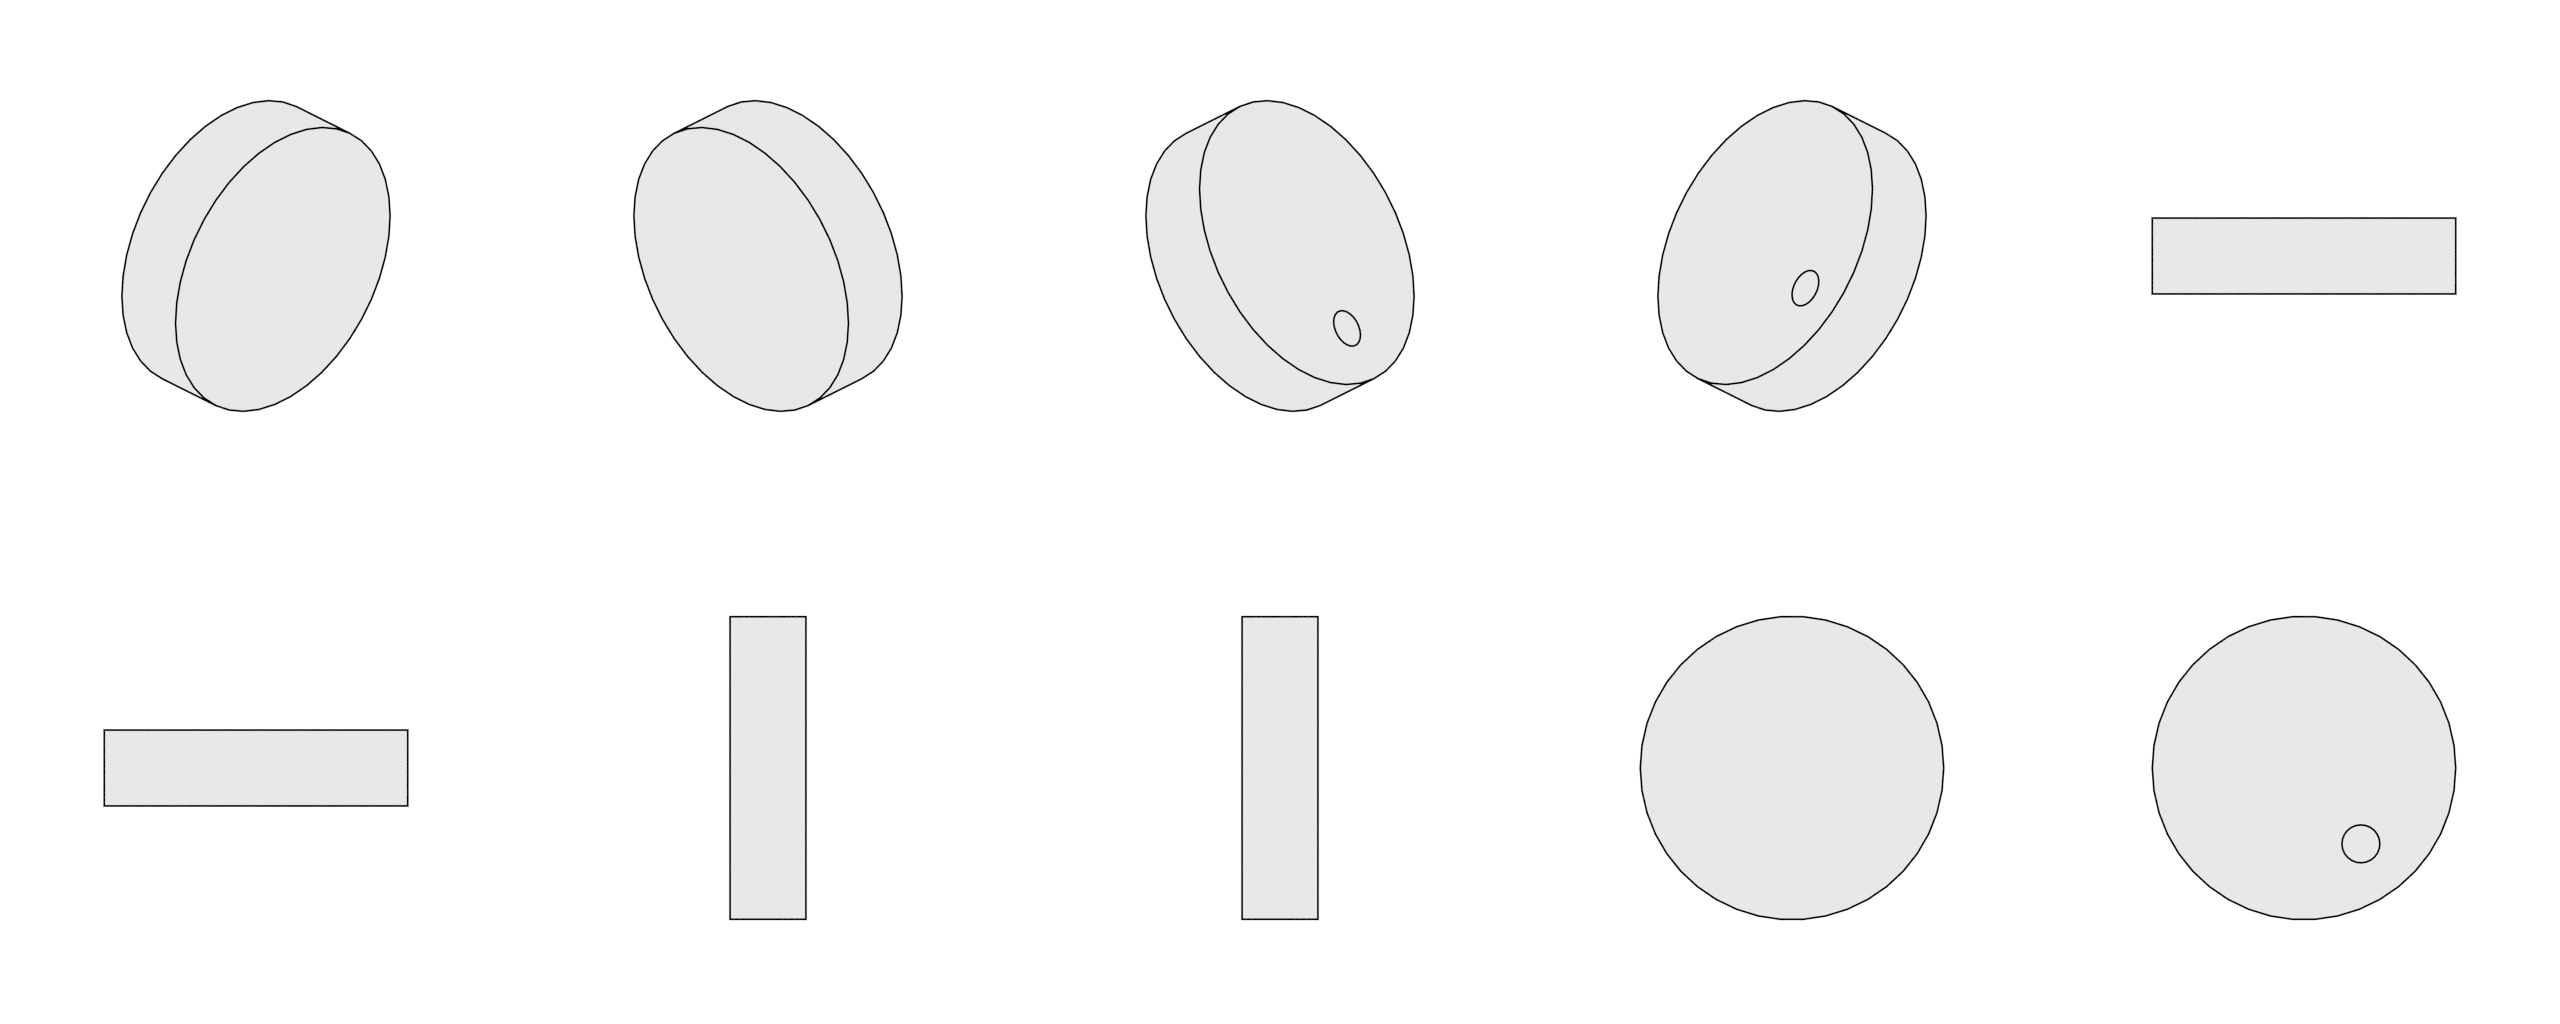

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

# Use either a list `converted_list` or a Dataset `conv_ds`.
# Example uses `converted_list`.
convo = converted_list[0]            # first conversation
msg0  = convo["messages"][0]         # first user message
img   = msg0["content"][1]["image"]  # extract the stitched grid image

# Method 1: render directly in Notebook / Colab
display(img)


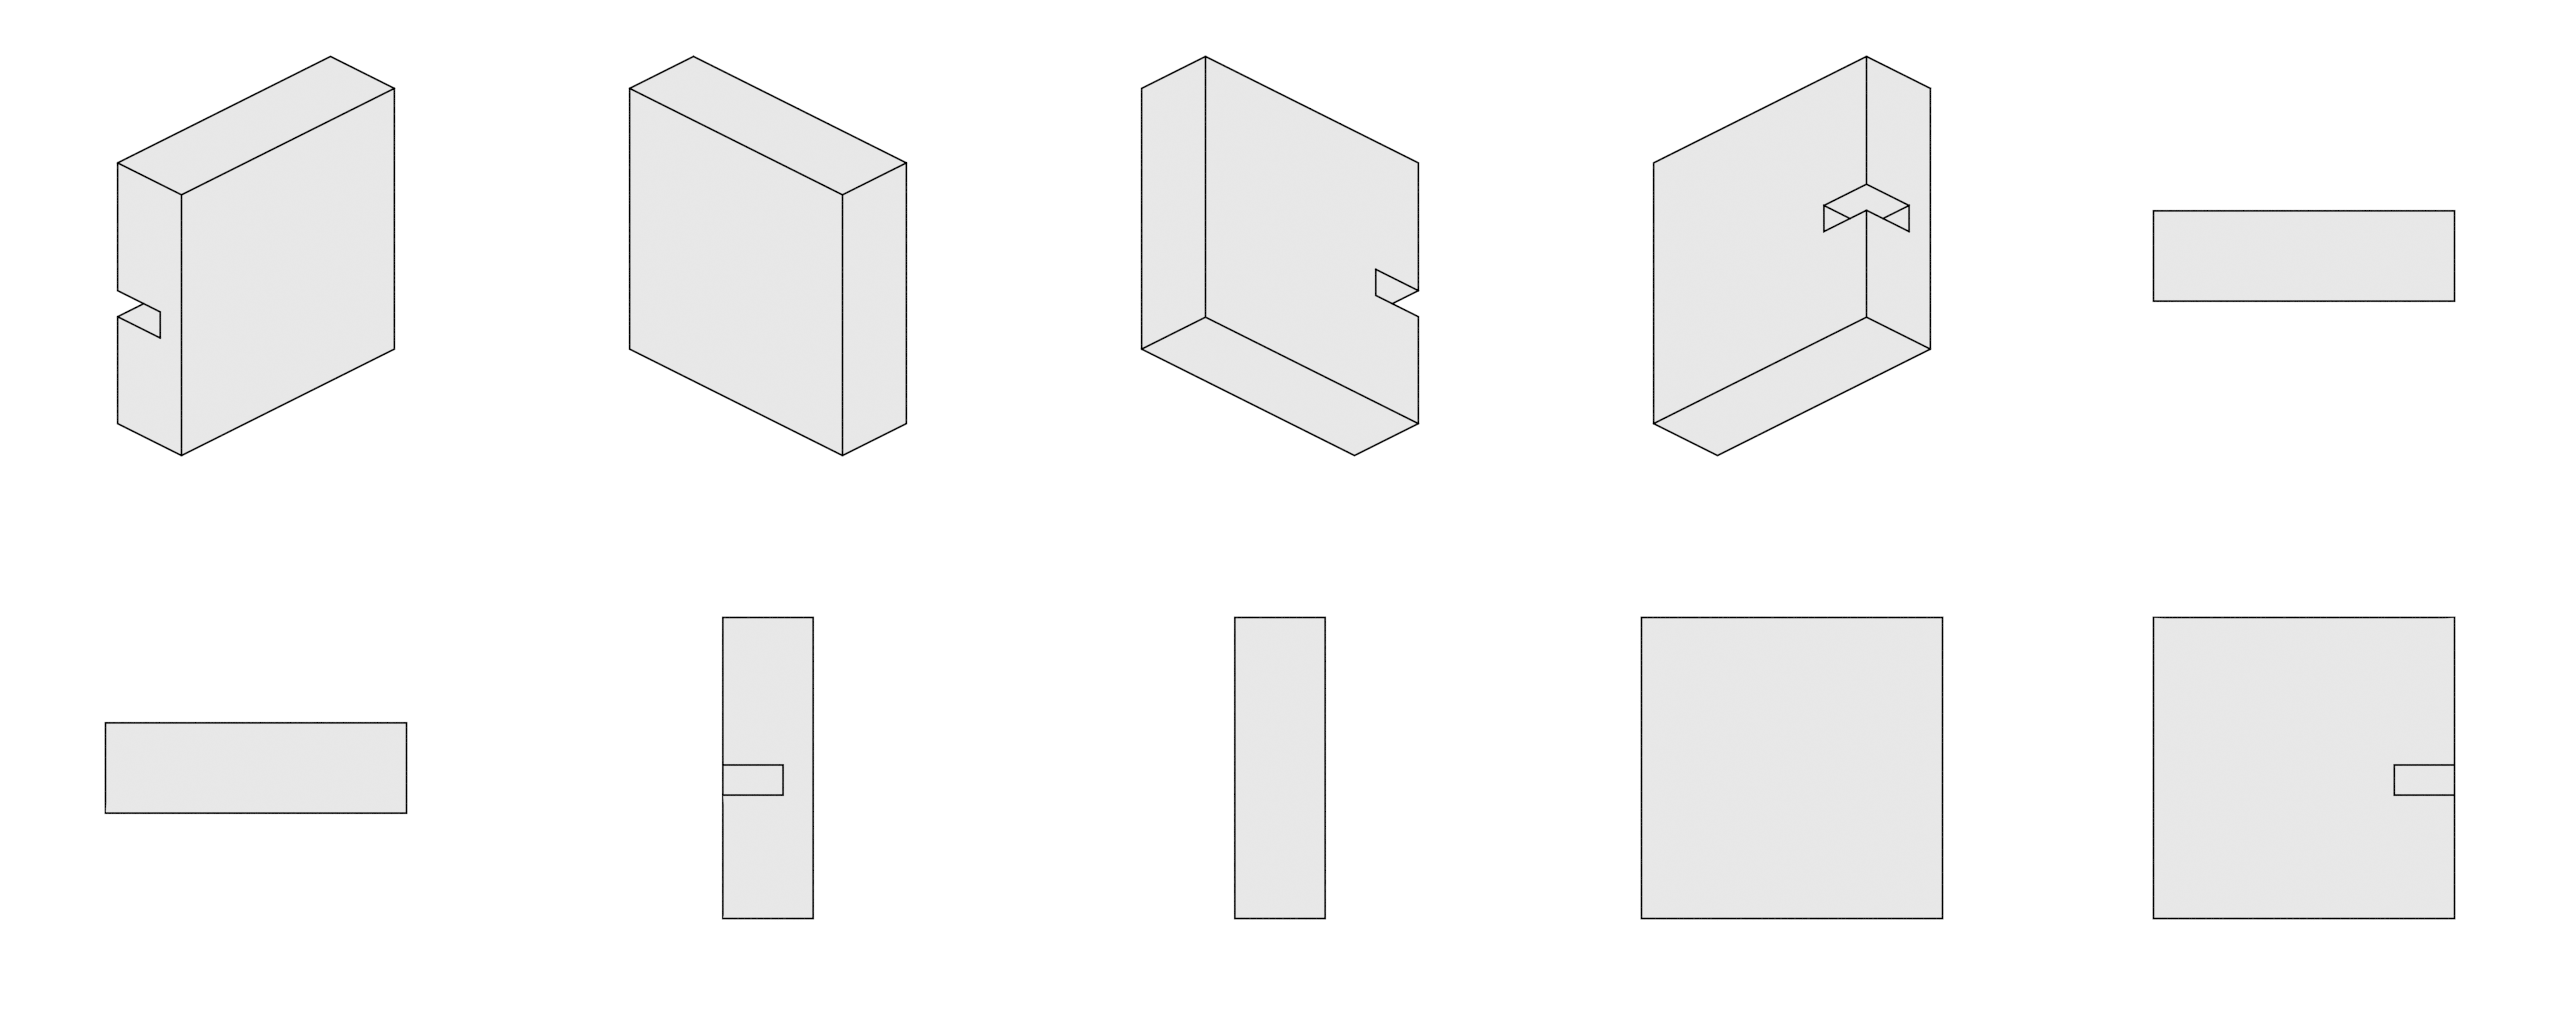

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

# Assume you have a list `converted_list` or a Dataset `conv_ds`.
# This example uses `test_dataset` as the source.
convo = test_dataset[0]             # first conversation record
msg0  = convo["messages"][0]        # first user message
img   = msg0["content"][1]["image"] # stitched grid image (second content item)

# Method 1: render directly in Notebook / Colab output cell
display(img)


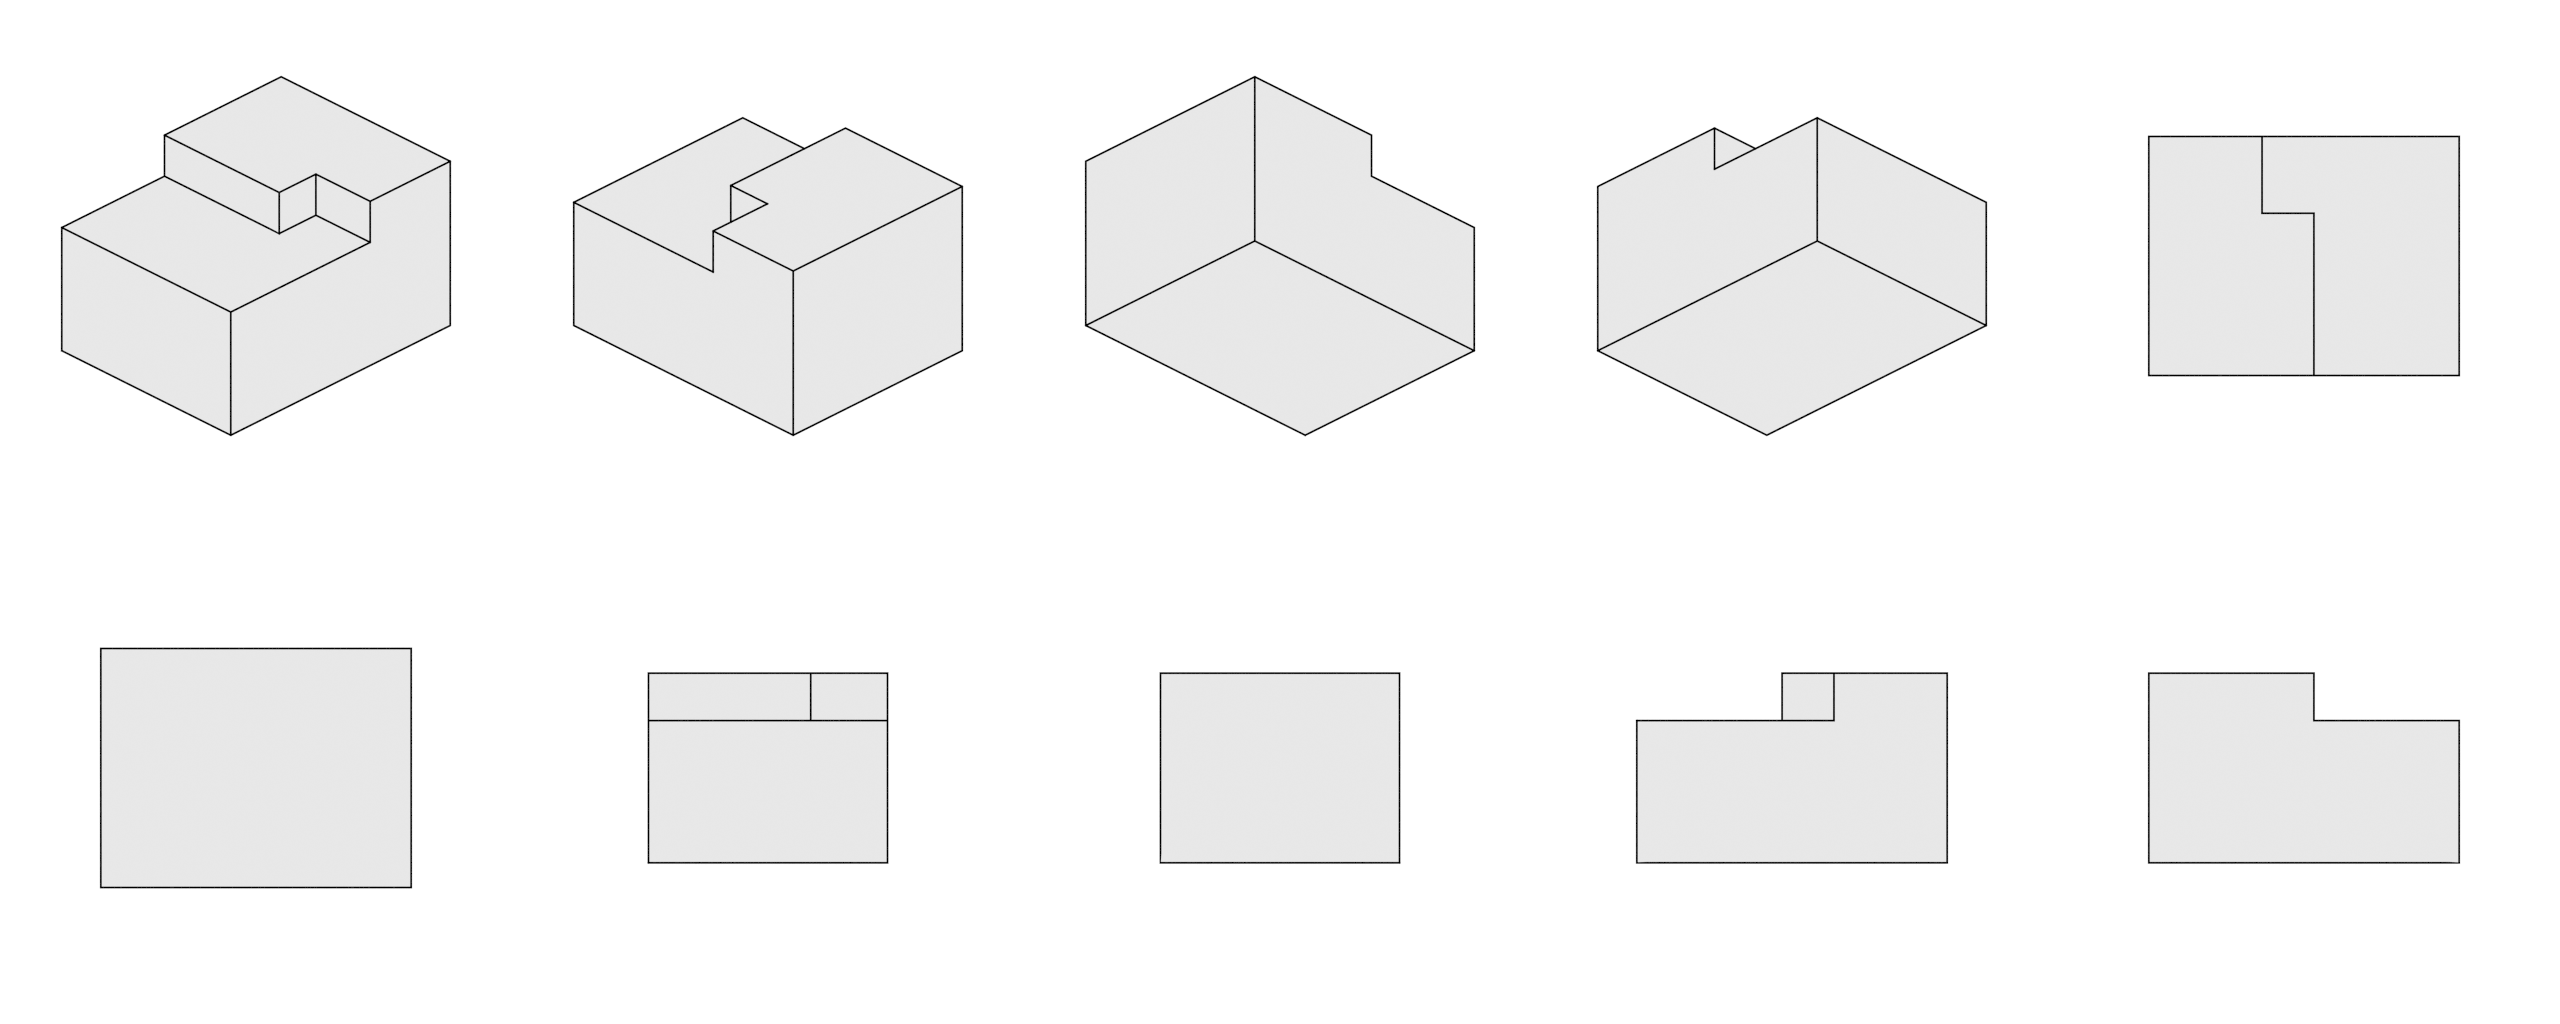

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

# Assume you have a list `converted_list` or a Dataset `conv_ds`.
# This example uses `contrast_dataset`.
convo = contrast_dataset[0]             # first conversation record
msg0  = convo["messages"][0]            # first user (user) message
img   = msg0["content"][1]["image"]     # extract the stitched grid image

# Method 1: render directly in Notebook / Colab output cell
display(img)


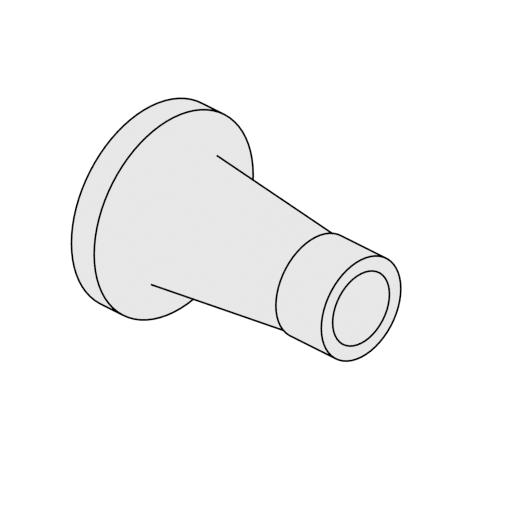

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

# Assume you have a list `converted_list` or a Dataset `conv_ds`.
# This example uses `train_contrast1000_dataset`.
convo = train_contrast1000_dataset[17]            # conversation at index 17
msg0  = convo["messages"][0]                      # first user message
img   = msg0["content"][1]["image"]               # stitched grid image (second content item)

# Method 1: render directly in Notebook / Colab output cell
display(img)


<a name="Train"></a>
### Train the model
Now let's use Huggingface TRL's `SFTTrainer`! More docs here: [TRL SFT docs](https://huggingface.co/docs/trl/sft_trainer). We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support TRL's `DPOTrainer`!

We use our new `UnslothVisionDataCollator` which will help in our vision finetuning setup.

In [ ]:
# ======================== 0. Dependencies ========================
import torch
from unsloth import FastVisionModel, is_bfloat16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

# Ensure the model expects a single image slot per sample — important.
model.config.image_slots = 1  # <- key

# ------------------------ 2. Enable training mode ------------------
FastVisionModel.for_training(model)   # Freeze backbone and inject LoRA
model.config.use_cache = False        # Disable cache — better training compatibility

tokenizer.model_max_length = 4096

# ------------------------ 3. Configure SFTConfig -------------------
sft_config = SFTConfig(
    # ----- Core hyperparameters -----
    per_device_train_batch_size   = 8,      # mini-batch size per device
    gradient_accumulation_steps   = 2,      # gradient accumulation steps
    num_train_epochs              = 4,      # number of training epochs
    warmup_ratio                  = 0.05,   # warmup fraction (5%)
    learning_rate                 = 1e-4,   # base learning rate
    logging_steps                 = 10,     # log every N steps
    optim                         = "adamw_8bit",
    weight_decay                  = 0.01,
    lr_scheduler_type             = "linear",
    seed                          = 3407,
    output_dir                    = "outputs",
    report_to                     = "none",  # set to "wandb" to report to Weights & Biases

    # ----- Vision LoRA / dataset settings (required) -----
    average_tokens_across_devices = False,
    remove_unused_columns         = False,
    dataset_text_field            = "messages",           # dataset field that contains text+image content
    dataset_kwargs                = {"skip_prepare_dataset": True},
    dataset_num_proc              = 4,                    # parallel processes for dataset preparation
    max_seq_length                = 4096,

    # ----- Mixed precision & memory -----
    bf16                          = is_bfloat16_supported(),  # use bfloat16 when supported
    fp16                          = not is_bfloat16_supported(), # otherwise use fp16

    # ----- Evaluation / checkpointing -----
    eval_strategy   = "steps",
    save_strategy   = "steps",
    eval_steps                    = 50,    # run evaluation every 50 steps
    save_steps      = 50,                    # save checkpoint every 50 steps
    save_total_limit              = 4,     # keep at most 4 checkpoints
    load_best_model_at_end        = True,
    metric_for_best_model         = "eval_loss",
)

# ------------------------ 4. Build data collator / trainer -----------------
collator = UnslothVisionDataCollator(
    model,
    tokenizer,                 # combined processor (tokenizer + image processor)
    resize=(1024, 2560),       # (height, width) — override only this, keep other defaults
    max_seq_length=4096,       # must match SFTConfig.max_seq_length
)

collator.truncation = False
print("Collator will resize images to:", collator.image_size)

# ------------------------ 4. Construct Trainer -----------------
trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    data_collator = collator,
    train_dataset = converted_list,
    eval_dataset  = val_dataset,     # prepared validation dataset
    args          = sft_config,
)

# Callback that prints training and eval loss to stdout
from transformers import TrainerCallback

class SafeLossLogger(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            step = state.global_step
            # Print training loss every 10 steps (when available)
            if "loss" in logs and step % 10 == 0:
                print(f"📝 Step {step} | Training Loss: {logs['loss']:.4f}")
            # Print eval loss whenever it's reported
            if "eval_loss" in logs:
                print(f"✅ Step {step} | Eval Loss: {logs['eval_loss']:.4f}")

trainer.add_callback(SafeLossLogger())


Collator will resize images to: (1024, 2560)


In [ ]:
# Grab one dataloader batch
train_dl = trainer.get_train_dataloader()
batch = next(iter(train_dl))

# Images are expected under batch["pixel_values"]
# Typical tensor shape: (batch_size, image_slots, channels, H, W)
imgs = batch["pixel_values"]
print("Images tensor shape:", imgs.shape)
# e.g. torch.Size([8, 1, 3, 512, 1280])


Images tensor shape: torch.Size([8, 4, 3, 336, 336])


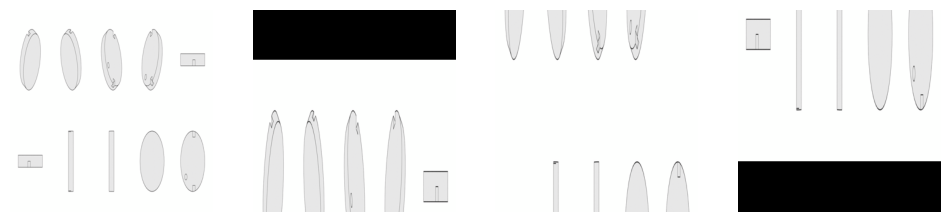

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Grab one batch and take all image slots from the first sample
batch = next(iter(trainer.get_train_dataloader()))
pv = batch["pixel_values"][0]           # tensor shape: [num_slots, 3, H, W]
pv = pv.cpu().to(torch.float32)

# 2. De-normalize (CLIP mean/std shown here).
#    If you use a different processor, replace with its mean/std.
mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1,3,1,1)
std  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1,3,1,1)
pv = pv * std + mean                    # shape remains [num_slots, 3, H, W]

# 3. Clamp values into [0, 1] for valid image display
pv = torch.clamp(pv, 0.0, 1.0)

# 4. Plot each image slot (convert to H x W x 3 for matplotlib)
fig, axes = plt.subplots(1, pv.shape[0], figsize=(12, 3))
for i in range(pv.shape[0]):
    img = pv[i].permute(1, 2, 0).numpy()  # H x W x 3
    axes[i].imshow(img)
    axes[i].axis("off")
plt.show()


In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA A100-SXM4-40GB. Max memory = 39.557 GB.
7.287 GB of memory reserved.


In [ ]:
trainer_stats = trainer.train()

Unsloth: Will smartly offload gradients to save VRAM!
{'loss': 0.9537, 'grad_norm': 3.51878023147583, 'learning_rate': 3.91304347826087e-05, 'epoch': 0.08888888888888889}
📝 Step 10 | Training Loss: 0.9537
{'loss': 0.0576, 'grad_norm': 0.12574191391468048, 'learning_rate': 8.260869565217392e-05, 'epoch': 0.17777777777777778}
📝 Step 20 | Training Loss: 0.0576
{'loss': 0.0076, 'grad_norm': 0.11231181770563126, 'learning_rate': 9.86013986013986e-05, 'epoch': 0.26666666666666666}
📝 Step 30 | Training Loss: 0.0076
{'loss': 0.0073, 'grad_norm': 0.029187582433223724, 'learning_rate': 9.627039627039628e-05, 'epoch': 0.35555555555555557}
📝 Step 40 | Training Loss: 0.0073
{'loss': 0.0072, 'grad_norm': 0.05040920898318291, 'learning_rate': 9.393939393939395e-05, 'epoch': 0.4444444444444444}
📝 Step 50 | Training Loss: 0.0072
{'eval_loss': 0.006913183256983757, 'eval_runtime': 101.2841, 'eval_samples_per_second': 1.975, 'eval_steps_per_second': 0.494, 'epoch': 0.4444444444444444}
✅ Step 50 | Eval Lo

In [ ]:
# After phase 1 finishes, grab the best checkpoint path
best_ckpt_1 = trainer.state.best_model_checkpoint
print("Phase 1 best checkpoint:", best_ckpt_1)


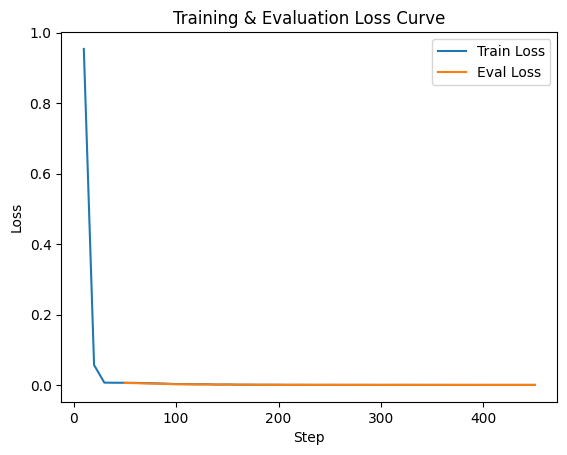

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

# trainer.train() has finished

# 1. Convert logs to a DataFrame
logs = trainer.state.log_history
df = pd.DataFrame(logs)

# 2. Separate training loss and evaluation loss
df_train = df[df['loss'].notnull()]
df_eval  = df[df['eval_loss'].notnull()]

# 3. Plot the curves
plt.figure()
plt.plot(df_train['step'], df_train['loss'],  label='Train Loss')
plt.plot(df_eval['step'],  df_eval['eval_loss'], label='Eval Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training & Evaluation Loss Curve')
plt.legend()
plt.show()


# One step - Stitch image input

In [ ]:
# 1. set output path
output_path = "/content/drive/MyDrive/fine_tuned_model-llava1-twostep"

# 2. save current Trainer model weights (includes LoRA adapter) and tokenizer config
trainer.save_model(output_path)
trainer.tokenizer.save_pretrained(output_path)

# 3. save training state (optimizer, lr_scheduler, global_step, rng state, etc.)
trainer.save_state()

print(f"✅ Saved to {output_path}; folder contains model weights, tokenizer files, and training state files (optimizer.pt, scheduler.pt, trainer_state.json, rng_state.pth, etc.)")


In [ ]:
# ---------------------------------------------
# 1. Dependencies & data preparation
# ---------------------------------------------
import torch
from torch.utils.data import Dataset, ConcatDataset
from datasets import load_from_disk
from unsloth import FastVisionModel, is_bfloat16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from transformers import TrainerCallback

# 1.1 Custom small list -> Dataset
class ListDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

# Assume train_contrast1000_dataset is already a list of 51 dicts
train_ds = ListDataset(train_contrast1000_dataset)
# 5x oversample
train_os = ConcatDataset([train_ds] * 5)

# ---------------------------------------------
# 2. Load phase-1 model & enable training mode
# ---------------------------------------------
# 2.1 Load model (with LoRA adapter) from the previously saved directory
model, tokenizer = FastVisionModel.from_pretrained(
    model_name="/content/drive/MyDrive/fine_tuned_model-llava1-twostep",
    dtype=torch.bfloat16 if is_bfloat16_supported() else torch.float16,
    load_in_4bit=False,
)

# 2.2 Freeze backbone; train only adapters
FastVisionModel.for_training(model)
model.config.use_cache = False
tokenizer.model_max_length = 4096

# ---------------------------------------------
# 3. SFTConfig: hyperparameters & regularization
# ---------------------------------------------
sft_config = SFTConfig(
    # —— Few samples: longer training & stronger regularization ——
    num_train_epochs              = 3,       # run more epochs
    per_device_train_batch_size   = 8,       # small batch
    gradient_accumulation_steps   = 2,       # effective batch size = 16
    learning_rate                 = 2e-5,    # lower LR
    warmup_ratio                  = 0.1,     # 10% warmup
    optim                         = "adamw_8bit",
    weight_decay                  = 0.05,    # stronger L2 regularization
    lr_scheduler_type             = "linear",
    seed                          = 3407,
    output_dir                    = "outputs_phase2",
    report_to                     = "none",
    logging_steps                 = 1,

    # —— Vision LoRA & data pipeline ——
    bf16                          = is_bfloat16_supported(),
    fp16                          = not is_bfloat16_supported(),
    average_tokens_across_devices = False,
    remove_unused_columns         = False,
    dataset_text_field            = "messages",
    dataset_kwargs                = {"skip_prepare_dataset": True},
    dataset_num_proc              = 4,
    max_seq_length                = 4096,

    # —— Save & eval strategy (can add early stopping) ——
    save_strategy                 = "epoch",     # optional: save once per epoch
)

# ---------------------------------------------
# 4. Build DataCollator
# ---------------------------------------------
collator = UnslothVisionDataCollator(
    model,
    tokenizer,
    resize=(1024, 2560),   # height x width for stitched images; adjust if needed
    max_seq_length=4096,
)
collator.truncation = False
print("Collator will resize images to:", collator.image_size)

# ---------------------------------------------
# 5. Custom logging Callback
# ---------------------------------------------
class LossLogger(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kw):
        if logs and "loss" in logs and state.global_step % args.logging_steps == 0:
            print(f"📝 Step {state.global_step} | Train Loss: {logs['loss']:.4f}")
        if logs and "eval_loss" in logs:
            print(f"✅ Step {state.global_step} | Eval Loss: {logs['eval_loss']:.4f}")

# ---------------------------------------------
# 6. Construct Trainer and start training
# ---------------------------------------------
trainer = SFTTrainer(
    model           = model,
    tokenizer       = tokenizer,
    train_dataset   = train_os,
    data_collator   = collator,
    args            = sft_config,
)
trainer.add_callback(LossLogger())


==((====))==  Unsloth 2025.7.7: Fast Llava patching. Transformers: 4.53.2.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.161 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.9. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Collator will resize images to: (1024, 2560)


In [ ]:
# Grab a dataloader
train_dl = trainer.get_train_dataloader()
batch = next(iter(train_dl))

# Assume image tensors are stored in batch["pixel_values"]
# Typical shape is (batch_size, image_slots, channels, H, W)
imgs = batch["pixel_values"]
print("Images tensor shape:", imgs.shape)
# e.g.: torch.Size([8, 1, 3, 512, 1280])


Images tensor shape: torch.Size([8, 4, 3, 336, 336])


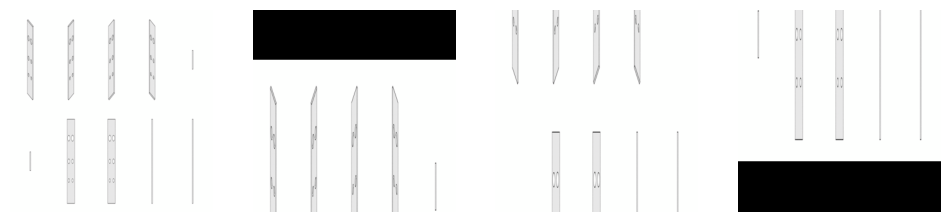

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Grab one batch and take all image slots from the first sample
batch = next(iter(trainer.get_train_dataloader()))
pv = batch["pixel_values"][0]           # shape: [4,3,H,W]
pv = pv.cpu().to(torch.float32)

# 2. De-normalize (CLIP mean/std shown; replace with your processor's mean/std if different)
mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1,3,1,1)
std  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1,3,1,1)
pv = pv * std + mean                     # shape still [4,3,H,W]

# 3. Clamp values to [0, 1]
pv = torch.clamp(pv, 0.0, 1.0)

# 4. Plot each image slot
fig, axes = plt.subplots(1, 4, figsize=(12,3))
for i in range(4):
    img = pv[i].permute(1,2,0).numpy()  # H×W×3
    axes[i].imshow(img)
    axes[i].axis("off")
plt.show()


In [ ]:
trainer.train()

Unsloth: Will smartly offload gradients to save VRAM!
{'loss': 0.0205, 'grad_norm': 0.41356199979782104, 'learning_rate': 0.0, 'epoch': 0.0392156862745098}
📝 Step 1 | Train Loss: 0.0205
{'loss': 0.0261, 'grad_norm': 0.41989272832870483, 'learning_rate': 2.5e-06, 'epoch': 0.0784313725490196}
📝 Step 2 | Train Loss: 0.0261
{'loss': 0.0224, 'grad_norm': 0.4341545104980469, 'learning_rate': 5e-06, 'epoch': 0.11764705882352941}
📝 Step 3 | Train Loss: 0.0224
{'loss': 0.0195, 'grad_norm': 0.3452988564968109, 'learning_rate': 7.500000000000001e-06, 'epoch': 0.1568627450980392}
📝 Step 4 | Train Loss: 0.0195
{'loss': 0.0172, 'grad_norm': 0.26973333954811096, 'learning_rate': 1e-05, 'epoch': 0.19607843137254902}
📝 Step 5 | Train Loss: 0.0172
{'loss': 0.0103, 'grad_norm': 0.1905120462179184, 'learning_rate': 1.25e-05, 'epoch': 0.23529411764705882}
📝 Step 6 | Train Loss: 0.0103
{'loss': 0.0104, 'grad_norm': 0.16166166961193085, 'learning_rate': 1.5000000000000002e-05, 'epoch': 0.27450980392156865}
📝

TrainOutput(global_step=78, training_loss=0.008532891205201546, metrics={'train_runtime': 2889.5846, 'train_samples_per_second': 0.265, 'train_steps_per_second': 0.027, 'total_flos': 9.640417886539776e+16, 'train_loss': 0.008532891205201546})

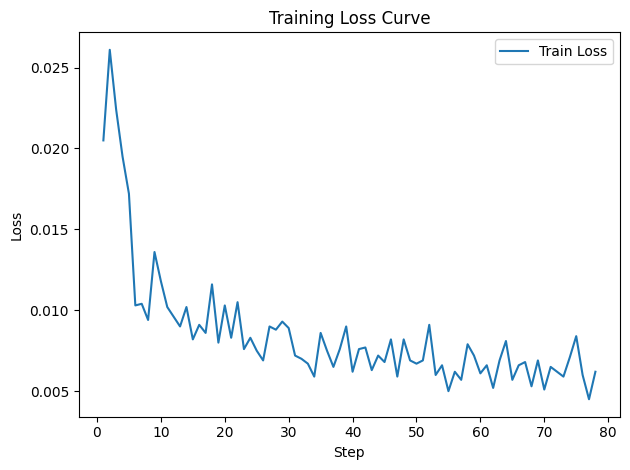

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# trainer.train() has finished
logs = trainer.state.log_history
df   = pd.DataFrame(logs)

# Keep only rows that contain a loss value
df_train = df[df["loss"].notnull()]

plt.figure()
plt.plot(df_train["step"], df_train["loss"], label="Train Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()


# Twostep - Stitch image input

In [ ]:
# 1. set output path
output_path = "/content/drive/MyDrive/fine_tuned_model-llava-twostep-combinepicture"

# 2. save current Trainer model weights (includes LoRA adapter) and tokenizer config
trainer.save_model(output_path)
trainer.tokenizer.save_pretrained(output_path)

# 3. save training state (optimizer, lr_scheduler, global_step, rng state, etc.)
trainer.save_state()

print(f"✅ Saved to {output_path}; directory contains model weights, tokenizer files, and training state files (optimizer.pt, scheduler.pt, trainer_state.json, rng_state.pth, etc.)")


In [ ]:
# ---------------------------------------------
# 1. Dependencies & data preparation
# ---------------------------------------------
import torch
from torch.utils.data import Dataset, ConcatDataset
from datasets import load_from_disk
from unsloth import FastVisionModel, is_bfloat16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from transformers import TrainerCallback

# 1.1 Custom small list -> Dataset
class ListDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

# Assume train_contrast1000_dataset is already a list of 51 dicts
train_ds = ListDataset(train_contrast1000_dataset)
# 5x oversample
train_os = ConcatDataset([train_ds] * 5)

# ---------------------------------------------
# 2. Load phase-1 model & enable training mode
# ---------------------------------------------
# 2.1 Load model (with LoRA adapter) from the previously saved directory
model, tokenizer = FastVisionModel.from_pretrained(
    model_name="/content/drive/MyDrive/fine_tuned_model-llava1-twostep",
    dtype=torch.bfloat16 if is_bfloat16_supported() else torch.float16,
    load_in_4bit=False,
)

# 2.2 Freeze backbone, train only adapters
FastVisionModel.for_training(model)
model.config.use_cache = False
tokenizer.model_max_length = 4096
model.config.image_slots     = 10

# ---------------------------------------------
# 3. SFTConfig: hyperparameters & regularization
# ---------------------------------------------
sft_config = SFTConfig(
    # -- Few samples: longer training & stronger regularization --
    num_train_epochs              = 3,       # run more epochs
    per_device_train_batch_size   = 8,       # small batch
    gradient_accumulation_steps   = 2,       # effective batch size = 16
    learning_rate                 = 2e-5,    # lower LR
    warmup_ratio                  = 0.1,     # 10% warmup
    optim                         = "adamw_8bit",
    weight_decay                  = 0.05,    # stronger L2 regularization
    lr_scheduler_type             = "linear",
    seed                          = 3407,
    output_dir                    = "outputs_phase2",
    report_to                     = "none",
    logging_steps                 = 1,

    # -- Vision LoRA & data pipeline --
    bf16                          = is_bfloat16_supported(),
    fp16                          = not is_bfloat16_supported(),
    average_tokens_across_devices = False,
    remove_unused_columns         = False,
    dataset_text_field            = "messages",
    dataset_kwargs                = {"skip_prepare_dataset": True},
    dataset_num_proc              = 4,
    max_seq_length                = 4096,

    # -- Save & eval strategy (can add early stopping) --
    save_strategy                 = "epoch",     # optional: save once per epoch
)

# ---------------------------------------------
# 4. Build DataCollator
# ---------------------------------------------
collator = UnslothVisionDataCollator(
    model,
    tokenizer,
    max_seq_length=4096,
)
collator.truncation = False
print("Collator will resize images to:", collator.image_size)

# ---------------------------------------------
# 5. Custom logging Callback
# ---------------------------------------------
class LossLogger(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kw):
        if logs and "loss" in logs and state.global_step % args.logging_steps == 0:
            print(f"📝 Step {state.global_step} | Train Loss: {logs['loss']:.4f}")
        if logs and "eval_loss" in logs:
            print(f"✅ Step {state.global_step} | Eval Loss: {logs['eval_loss']:.4f}")

# ---------------------------------------------
# 6. Construct Trainer and start training
# ---------------------------------------------
trainer = SFTTrainer(
    model           = model,
    tokenizer       = tokenizer,
    train_dataset   = train_os,
    data_collator   = collator,
    args            = sft_config,
)
trainer.add_callback(LossLogger())


==((====))==  Unsloth 2025.7.8: Fast Llava_Next patching. Transformers: 4.53.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Collator will resize images to: 336


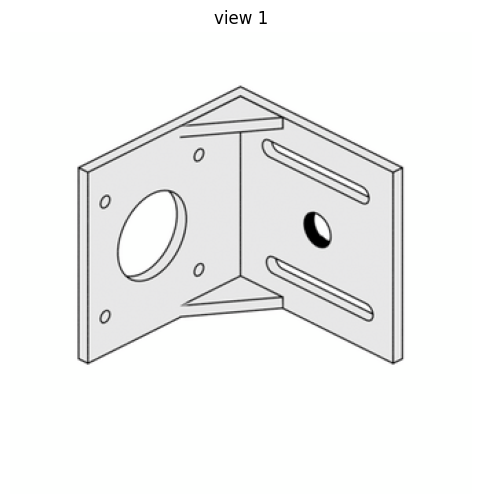

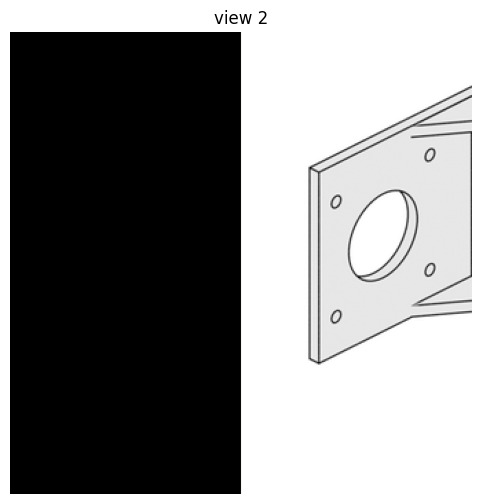

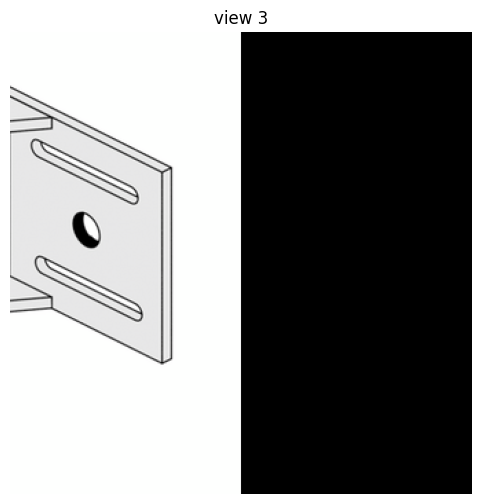

In [ ]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch

# Grab one batch
loader = DataLoader(train_os, batch_size=1, shuffle=True, collate_fn=collator)
batch = next(iter(loader))
pv    = batch["pixel_values"]  # shape: [1, slots, 3, H, W]

# Denormalization params (same as used during training)
mean = torch.tensor([0.48145466, 0.4578275, 0.40821073],
                    device=pv.device)[None,:,None,None]
std  = torch.tensor([0.26862954, 0.26130258, 0.27577711],
                    device=pv.device)[None,:,None,None]

# Extract all images -> (slots, H, W, 3)
imgs = (pv[0] * std + mean).permute(0,2,3,1).cpu().numpy()
num_imgs = imgs.shape[0]

# Display each image individually
for idx in range(num_imgs):
    plt.figure(figsize=(6,6))
    plt.imshow(imgs[idx].clip(0,1))
    plt.title(f"view {idx+1}")
    plt.axis("off")
    plt.show()


In [ ]:
trainer.train()

Unsloth: Will smartly offload gradients to save VRAM!
{'loss': 0.1057, 'grad_norm': 4.995660781860352, 'learning_rate': 0.0, 'epoch': 0.023529411764705882}
📝 Step 1 | Train Loss: 0.1057
{'loss': 0.1022, 'grad_norm': 4.908938884735107, 'learning_rate': 1.5384615384615387e-06, 'epoch': 0.047058823529411764}
📝 Step 2 | Train Loss: 0.1022
{'loss': 0.0963, 'grad_norm': 3.617537498474121, 'learning_rate': 3.0769230769230774e-06, 'epoch': 0.07058823529411765}
📝 Step 3 | Train Loss: 0.0963
{'loss': 0.0898, 'grad_norm': 2.1858460903167725, 'learning_rate': 4.615384615384616e-06, 'epoch': 0.09411764705882353}
📝 Step 4 | Train Loss: 0.0898
{'loss': 0.0774, 'grad_norm': 1.8269175291061401, 'learning_rate': 6.153846153846155e-06, 'epoch': 0.11764705882352941}
📝 Step 5 | Train Loss: 0.0774
{'loss': 0.0651, 'grad_norm': 1.4940582513809204, 'learning_rate': 7.692307692307694e-06, 'epoch': 0.1411764705882353}
📝 Step 6 | Train Loss: 0.0651
{'loss': 0.0512, 'grad_norm': 1.3467319011688232, 'learning_rate

TrainOutput(global_step=129, training_loss=0.011850392514507669, metrics={'train_runtime': 3920.2748, 'train_samples_per_second': 0.195, 'train_steps_per_second': 0.033, 'total_flos': 4.295671136127222e+17, 'train_loss': 0.011850392514507669})

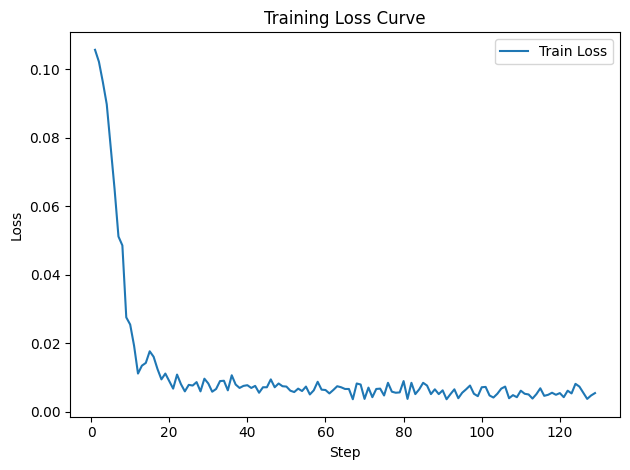

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# trainer.train() has finished
logs = trainer.state.log_history
df   = pd.DataFrame(logs)

# Keep only rows that contain a loss value
df_train = df[df["loss"].notnull()]

plt.figure()
plt.plot(df_train["step"], df_train["loss"], label="Train Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()


# Twostep - Separate image input

In [ ]:
# 1. set output path
output_path = "/content/drive/MyDrive/fine_tuned_model-llava-twostep-10picture"

# 2. save current Trainer model weights (includes LoRA adapter) and tokenizer config
trainer.save_model(output_path)
trainer.tokenizer.save_pretrained(output_path)

# 3. save training state (optimizer, lr_scheduler, global_step, rng state, etc.)
trainer.save_state()

print(f"✅ Saved successfully to {output_path}; directory contains model weights, tokenizer files, and training state files (optimizer.pt, scheduler.pt, trainer_state.json, rng_state.pth, etc.)")


# **Test in DatasetA**

# **original model**

In [ ]:
import os
import re
import json
import random
import gc
import torch
import pandas as pd
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

# ───── Mute logs & clear CUDA cache ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# ====== Hyperparams & config ======
MAX_TOKENS  = 256
BATCH_SIZE  = 20
VERBOSE     = True
TYPE_FIELDS = [
    "Through Hole", "Blind Hole", "Opened Pocket",
    "Closed Pocket", "Chamfer", "Fillet"
]
NUM_FIELDS = TYPE_FIELDS

# ====== Helper: extract complete JSON from a raw model output ======
def extract_json(raw: str) -> str:
    raw = raw.strip()
    if raw.startswith("```"):
        raw = "\n".join(raw.splitlines()[1:-1])
    start = raw.find("{")
    if start == -1:
        return raw
    depth = 0
    for i, ch in enumerate(raw[start:], start):
        depth += (ch == "{")
        depth -= (ch == "}")
        if depth == 0:
            return raw[start:i+1]
    return raw[start:]

# ====== Text cleaning ======
def clean_text(txt: str, image_token="<image>") -> str:
    txt = re.sub(r"\[/?INST\]", "", txt, flags=re.IGNORECASE)
    txt = txt.replace(image_token, "")
    return re.sub(r"\n{2,}", "\n", txt).strip()

# ====== Utility: convert identified_features list to a dict ======
def features_to_dict(feature_list):
    d = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}
    for item in feature_list:
        name = item.get("feature_name")
        if name in d:
            d[name]["exists"] = bool(item.get("exists", False))
            try:
                d[name]["quantity"] = int(item.get("quantity", 0))
            except:
                pass
    return d

# ====== 1. Load model & set inference mode ======
adapter_dir = "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit"
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_dir, load_in_4bit=True, device_map="auto"
)
FastVisionModel.for_inference(model)
model.eval()

# ====== 2. Build collator ======
collator = UnslothVisionDataCollator(
    model, tokenizer,
    resize=(1024, 2560),
    max_seq_length=4096
)
collator.truncation = False
IMAGE_TOKEN = getattr(collator, "image_token", "<image>")

# ====== 3. Prepare data ======
dataset = test_dataset
idxs = list(range(len(dataset)))
random.seed(42)
random.shuffle(idxs)
print(f"✅ Inference & Evaluation on {len(dataset)} samples")

# ====== 4. Inference & collect results ======
rows = []
skip_count = 0

for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Evaluating"):
    batch_idxs = idxs[start : start + BATCH_SIZE]

    # Build inputs
    inputs = []
    for i in batch_idxs:
        msgs = [m for m in dataset[i]["messages"] if m["role"] != "assistant"]
        cleaned = []
        for m in msgs:
            new_content = []
            for elem in m["content"]:
                if elem.get("type") == "text":
                    new_content.append({
                        "type": "text",
                        "text": clean_text(elem["text"], IMAGE_TOKEN)
                    })
                else:
                    new_content.append(elem)
            cleaned.append({"role": m["role"], "content": new_content})
        inputs.append({"messages": cleaned})

    # Inference
    batch = collator(inputs)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    inp_len = batch["input_ids"].shape[-1]
    with torch.no_grad():
        out_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=1,
        )
    preds = tokenizer.batch_decode(out_ids[:, inp_len:], skip_special_tokens=True)

    # Parse & collect
    for idx, raw in zip(batch_idxs, preds):
        gt_txt   = dataset[idx]["messages"][-1]["content"][0]["text"].strip()
        pred_txt = extract_json(raw)
        try:
            gt = json.loads(gt_txt)
            pred = json.loads(pred_txt)
            gt_feats   = features_to_dict(gt.get("identified_features", []))
            pred_feats = features_to_dict(pred.get("identified_features", []))
        except json.JSONDecodeError:
            if VERBOSE:
                print(f"[⚠️ Parse fail idx={idx}] raw={raw!r}")
            skip_count += 1
            gt = json.loads(gt_txt)
            gt_feats   = features_to_dict(gt.get("identified_features", []))
            pred_feats = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}

        row = {}
        for f in TYPE_FIELDS:
            row[f + "_gt"]          = gt_feats[f]["quantity"]
            row[f + "_pred"]        = pred_feats[f]["quantity"]
            row[f + "_exists_gt"]   = gt_feats[f]["exists"]
            row[f + "_exists_pred"] = pred_feats[f]["exists"]
        rows.append(row)

        if VERBOSE:
            print(f"\n--- Sample {idx} ---")
            print("GT  :", gt_txt)
            print("PRED:", pred_txt)

    # Free memory
    del batch, out_ids, preds
    gc.collect()
    torch.cuda.empty_cache()

# ====== 5. Metrics & statistics ======
df = pd.DataFrame(rows)
print(f"✅ Collected {len(df)}/{len(dataset)} samples (parse-fail→all-wrong: {skip_count})")

# Basic matches
for f in TYPE_FIELDS:
    df[f + "_match"]        = df[f + "_gt"] == df[f + "_pred"]
    df[f + "_exists_match"] = df[f + "_exists_gt"] == df[f + "_exists_pred"]
all_matches = [f + "_match" for f in TYPE_FIELDS] + [f + "_exists_match" for f in TYPE_FIELDS]
df["exact_match"] = df[all_matches].all(axis=1)

# Basic metrics
exact_acc     = df["exact_match"].mean() * 100
numeric_acc   = df[[f + "_match" for f in TYPE_FIELDS]].mean(axis=1).mean() * 100
existence_acc = df[[f + "_exists_match" for f in TYPE_FIELDS]].mean(axis=1).mean() * 100
feature_acc   = df[all_matches].mean(axis=1).mean() * 100

print(f"▶ Exact Match        : {exact_acc:.2f}%")
print(f"▶ Numeric Acc        : {numeric_acc:.2f}%")
print(f"▶ Existence (Type)   : {existence_acc:.2f}%")
print(f"▶ Feature-level      : {feature_acc:.2f}%")
print("▶ Per-field Acc (qty/exist):")
for f in TYPE_FIELDS:
    print(f"   {f:8}: {df[f + '_match'].mean()*100:5.2f}% / {df[f + '_exists_match'].mean()*100:5.2f}%")

# FNA & FQA
tp_name = sum((df[f + "_exists_pred"] & df[f + "_exists_gt"]).sum() for f in TYPE_FIELDS)
total_gt_names = sum(df[f + "_exists_gt"].sum() for f in TYPE_FIELDS)
fna = tp_name / total_gt_names * 100 if total_gt_names else float("nan")

tp_qty = df.apply(
    lambda r: sum(min(r[f + "_gt"], r[f + "_pred"]) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty = df[[f + "_gt" for f in TYPE_FIELDS]].sum().sum()
fqa = tp_qty / total_gt_qty * 100 if total_gt_qty else float("nan")

print(f"▶ Feature Name Accuracy (FNA): {fna:.2f}%")
print(f"▶ Feature Quantity Accuracy (FQA): {fqa:.2f}%")

# ───────── Fine-grained & composite scoring ─────────
fp_name = sum((df[f + "_exists_pred"] & ~df[f + "_exists_gt"]).sum() for f in TYPE_FIELDS)
fn_name = sum((~df[f + "_exists_pred"] & df[f + "_exists_gt"]).sum() for f in TYPE_FIELDS)

name_precision = tp_name / (tp_name + fp_name) * 100 if (tp_name + fp_name) else float("nan")
name_recall    = tp_name / (tp_name + fn_name) * 100 if (tp_name + fn_name) else float("nan")
name_f1        = (
    2 * name_precision * name_recall /
    (name_precision + name_recall)
    if (name_precision + name_recall) else float("nan")
)

pred_qty_total = df[[f + "_pred" for f in TYPE_FIELDS]].sum().sum()
halluc_qty     = df.apply(
    lambda r: sum(max(r[f + "_pred"] - r[f + "_gt"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
halluc_rate    = halluc_qty / pred_qty_total * 100 if pred_qty_total else float("nan")

total_abs_error = df.apply(
    lambda r: sum(abs(r[f + "_pred"] - r[f + "_gt"]) for f in TYPE_FIELDS),
    axis=1
).sum()
mae            = total_abs_error / (len(df) * len(TYPE_FIELDS))

fn_qty             = df.apply(
    lambda r: sum(max(r[f + "_gt"] - r[f + "_pred"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
under_report_rate  = fn_qty / total_gt_qty * 100 if total_gt_qty else float("nan")

quantity_precision = tp_qty / pred_qty_total * 100 if pred_qty_total else float("nan")
quantity_recall    = tp_qty / total_gt_qty   * 100 if total_gt_qty   else float("nan")
quantity_f1        = (
    2 * quantity_precision * quantity_recall /
    (quantity_precision + quantity_recall)
    if (quantity_precision + quantity_recall) else float("nan")
)

alpha = 0.5
overall_score = alpha * name_f1 + (1 - alpha) * quantity_f1

print("────────────────────────────────────────────")
print(f"▶ Name Precision       : {name_precision:.2f}%")
print(f"▶ Name Recall (FNA)    : {name_recall:.2f}%")
print(f"▶ Name F1              : {name_f1:.2f}%")
print(f"▶ Hallucination Rate   : {halluc_rate:.2f}%")
print(f"▶ Mean Absolute Error  : {mae:.3f}")
print(f"▶ Under-report Rate    : {under_report_rate:.2f}%")
print(f"▶ Quantity Precision   : {quantity_precision:.2f}%")
print(f"▶ Quantity Recall (FQA): {quantity_recall:.2f}%")
print(f"▶ Quantity F1          : {quantity_f1:.2f}%")
print(f"▶ Overall Score (α={alpha}) : {overall_score:.2f}%")
print("────────────────────────────────────────────")


==((====))==  Unsloth 2025.7.8: Fast Llava_Next patching. Transformers: 4.53.3.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference & Evaluation on 200 samples


Evaluating:  10%|█         | 1/10 [01:05<09:46, 65.19s/it]


--- Sample 66 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Blind Hole",
            "exists": t

Evaluating:  20%|██        | 2/10 [01:44<06:37, 49.68s/it]


--- Sample 159 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Blind Hole",
            "exists":

...


--- Sample 58 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Blind Hole",
            "exists": 

Evaluating:  90%|█████████ | 9/10 [06:12<00:38, 38.90s/it]


--- Sample 86 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Blind Hole",
            "exists":

Evaluating: 100%|██████████| 10/10 [06:51<00:00, 41.14s/it]


--- Sample 59 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Blind Hole",
            "exists": 

# **one step fine tuned model**

In [ ]:
import os
import re
import json
import random
import gc
import torch
import pandas as pd
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

# ───── Mute logs & clear CUDA cache ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# ====== Hyperparams & config ======
MAX_TOKENS  = 256
BATCH_SIZE  = 20
VERBOSE     = True
TYPE_FIELDS = [
    "Through Hole", "Blind Hole", "Opened Pocket",
    "Closed Pocket", "Chamfer", "Fillet"
]
NUM_FIELDS = TYPE_FIELDS

# ====== Helper: extract complete JSON from raw output ======
def extract_json(raw: str) -> str:
    raw = raw.strip()
    if raw.startswith("```"):
        raw = "\n".join(raw.splitlines()[1:-1])
    start = raw.find("{")
    if start == -1:
        return raw
    depth = 0
    for i, ch in enumerate(raw[start:], start):
        depth += (ch == "{")
        depth -= (ch == "}")
        if depth == 0:
            return raw[start:i+1]
    return raw[start:]

# ====== Text cleaning ======
def clean_text(txt: str, image_token="<image>") -> str:
    # Remove INST tags and image tokens, collapse multiple blank lines
    txt = re.sub(r"\[/?INST\]", "", txt, flags=re.IGNORECASE)
    txt = txt.replace(image_token, "")
    return re.sub(r"\n{2,}", "\n", txt).strip()

# ====== Utility: convert identified_features list to dict ======
def features_to_dict(feature_list):
    d = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}
    for item in feature_list:
        name = item.get("feature_name")
        if name in d:
            d[name]["exists"] = bool(item.get("exists", False))
            try:
                d[name]["quantity"] = int(item.get("quantity", 0))
            except:
                pass
    return d

# ====== 1. Load model & set inference mode ======
adapter_dir = "/content/drive/MyDrive/fine_tuned_model-llava1-twostep"
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_dir, load_in_4bit=True, device_map="auto"
)
FastVisionModel.for_inference(model)
model.eval()

# ====== 2. Build collator ======
collator = UnslothVisionDataCollator(
    model, tokenizer,
    resize=(1024, 2560),
    max_seq_length=4096
)
collator.truncation = False
IMAGE_TOKEN = getattr(collator, "image_token", "<image>")

# ====== 3. Prepare data ======
dataset = test_dataset
idxs = list(range(len(dataset)))
random.seed(42)
random.shuffle(idxs)
print(f"✅ Inference & Evaluation on {len(dataset)} samples")

# ====== 4. Inference & collect results ======
rows = []
skip_count = 0

for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Evaluating"):
    batch_idxs = idxs[start : start + BATCH_SIZE]

    # Build inputs
    inputs = []
    for i in batch_idxs:
        msgs = [m for m in dataset[i]["messages"] if m["role"] != "assistant"]
        cleaned = []
        for m in msgs:
            new_content = []
            for elem in m["content"]:
                if elem.get("type") == "text":
                    new_content.append({
                        "type": "text",
                        "text": clean_text(elem["text"], IMAGE_TOKEN)
                    })
                else:
                    new_content.append(elem)
            cleaned.append({"role": m["role"], "content": new_content})
        inputs.append({"messages": cleaned})

    # Inference
    batch = collator(inputs)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    inp_len = batch["input_ids"].shape[-1]
    with torch.no_grad():
        out_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=1,
        )
    preds = tokenizer.batch_decode(out_ids[:, inp_len:], skip_special_tokens=True)

    # Parse & collect
    for idx, raw in zip(batch_idxs, preds):
        gt_txt   = dataset[idx]["messages"][-1]["content"][0]["text"].strip()
        pred_txt = extract_json(raw)
        try:
            gt = json.loads(gt_txt)
            pred = json.loads(pred_txt)
            gt_feats   = features_to_dict(gt.get("identified_features", []))
            pred_feats = features_to_dict(pred.get("identified_features", []))
        except json.JSONDecodeError:
            if VERBOSE:
                print(f"[⚠️ Parse fail idx={idx}] raw={raw!r}")
            skip_count += 1
            gt = json.loads(gt_txt)
            gt_feats   = features_to_dict(gt.get("identified_features", []))
            pred_feats = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}

        row = {}
        for f in TYPE_FIELDS:
            row[f + "_gt"]          = gt_feats[f]["quantity"]
            row[f + "_pred"]        = pred_feats[f]["quantity"]
            row[f + "_exists_gt"]   = gt_feats[f]["exists"]
            row[f + "_exists_pred"] = pred_feats[f]["exists"]
        rows.append(row)

        if VERBOSE:
            print(f"\n--- Sample {idx} ---")
            print("GT  :", gt_txt)
            print("PRED:", pred_txt)

    # Free memory
    del batch, out_ids, preds
    gc.collect()
    torch.cuda.empty_cache()

# ====== 5. Metrics & statistics ======
df = pd.DataFrame(rows)
print(f"✅ Collected {len(df)}/{len(dataset)} samples (parse-fail→all-wrong: {skip_count})")

# Basic matches
for f in TYPE_FIELDS:
    df[f + "_match"]        = df[f + "_gt"] == df[f + "_pred"]
    df[f + "_exists_match"] = df[f + "_exists_gt"] == df[f + "_exists_pred"]
all_matches = [f + "_match" for f in TYPE_FIELDS] + [f + "_exists_match" for f in TYPE_FIELDS]
df["exact_match"] = df[all_matches].all(axis=1)

# Basic metrics
exact_acc     = df["exact_match"].mean() * 100
numeric_acc   = df[[f + "_match" for f in TYPE_FIELDS]].mean(axis=1).mean() * 100
existence_acc = df[[f + "_exists_match" for f in TYPE_FIELDS]].mean(axis=1).mean() * 100
feature_acc   = df[all_matches].mean(axis=1).mean() * 100

print(f"▶ Exact Match        : {exact_acc:.2f}%")
print(f"▶ Numeric Acc        : {numeric_acc:.2f}%")
print(f"▶ Existence (Type)   : {existence_acc:.2f}%")
print(f"▶ Feature-level      : {feature_acc:.2f}%")
print("▶ Per-field Acc (qty/exist):")
for f in TYPE_FIELDS:
    print(f"   {f:8}: {df[f + '_match'].mean()*100:5.2f}% / {df[f + '_exists_match'].mean()*100:5.2f}%")

# FNA & FQA
tp_name = sum((df[f + "_exists_pred"] & df[f + "_exists_gt"]).sum() for f in TYPE_FIELDS)
total_gt_names = sum(df[f + "_exists_gt"].sum() for f in TYPE_FIELDS)
fna = tp_name / total_gt_names * 100 if total_gt_names else float("nan")

tp_qty = df.apply(
    lambda r: sum(min(r[f + "_gt"], r[f + "_pred"]) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty = df[[f + "_gt" for f in TYPE_FIELDS]].sum().sum()
fqa = tp_qty / total_gt_qty * 100 if total_gt_qty else float("nan")

print(f"▶ Feature Name Accuracy (FNA): {fna:.2f}%")
print(f"▶ Feature Quantity Accuracy (FQA): {fqa:.2f}%")

# ───────── Fine-grained & composite scoring ─────────
fp_name = sum((df[f + "_exists_pred"] & ~df[f + "_exists_gt"]).sum() for f in TYPE_FIELDS)
fn_name = sum((~df[f + "_exists_pred"] & df[f + "_exists_gt"]).sum() for f in TYPE_FIELDS)

name_precision = tp_name / (tp_name + fp_name) * 100 if (tp_name + fp_name) else float("nan")
name_recall    = tp_name / (tp_name + fn_name) * 100 if (tp_name + fn_name) else float("nan")
name_f1        = (
    2 * name_precision * name_recall /
    (name_precision + name_recall)
    if (name_precision + name_recall) else float("nan")
)

pred_qty_total = df[[f + "_pred" for f in TYPE_FIELDS]].sum().sum()
halluc_qty     = df.apply(
    lambda r: sum(max(r[f + "_pred"] - r[f + "_gt"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
halluc_rate    = halluc_qty / pred_qty_total * 100 if pred_qty_total else float("nan")

total_abs_error = df.apply(
    lambda r: sum(abs(r[f + "_pred"] - r[f + "_gt"]) for f in TYPE_FIELDS),
    axis=1
).sum()
mae            = total_abs_error / (len(df) * len(TYPE_FIELDS))

fn_qty             = df.apply(
    lambda r: sum(max(r[f + "_gt"] - r[f + "_pred"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
under_report_rate  = fn_qty / total_gt_qty * 100 if total_gt_qty else float("nan")

quantity_precision = tp_qty / pred_qty_total * 100 if pred_qty_total else float("nan")
quantity_recall    = tp_qty / total_gt_qty   * 100 if total_gt_qty   else float("nan")
quantity_f1        = (
    2 * quantity_precision * quantity_recall /
    (quantity_precision + quantity_recall)
    if (quantity_precision + quantity_recall) else float("nan")
)

alpha = 0.5
overall_score = alpha * name_f1 + (1 - alpha) * quantity_f1

print("────────────────────────────────────────────")
print(f"▶ Name Precision       : {name_precision:.2f}%")
print(f"▶ Name Recall (FNA)    : {name_recall:.2f}%")
print(f"▶ Name F1              : {name_f1:.2f}%")
print(f"▶ Hallucination Rate   : {halluc_rate:.2f}%")
print(f"▶ Mean Absolute Error  : {mae:.3f}")
print(f"▶ Under-report Rate    : {under_report_rate:.2f}%")
print(f"▶ Quantity Precision   : {quantity_precision:.2f}%")
print(f"▶ Quantity Recall (FQA): {quantity_recall:.2f}%")
print(f"▶ Quantity F1          : {quantity_f1:.2f}%")
print(f"▶ Overall Score (α={alpha}) : {overall_score:.2f}%")
print("────────────────────────────────────────────")


==((====))==  Unsloth 2025.7.8: Fast Llava_Next patching. Transformers: 4.53.3.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference & Evaluation on 200 samples


Evaluating:  10%|█         | 1/10 [00:51<07:43, 51.47s/it]


--- Sample 66 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": 

Evaluating:  20%|██        | 2/10 [01:42<06:49, 51.17s/it]


--- Sample 159 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists"

...


--- Sample 58 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists":

Evaluating:  90%|█████████ | 9/10 [07:36<00:50, 50.58s/it]


--- Sample 86 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists"

Evaluating: 100%|██████████| 10/10 [08:27<00:00, 50.71s/it]


--- Sample 59 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists":

## **two step fine tuned model**

In [ ]:
import os
import re
import json
import random
import gc
import torch
import pandas as pd
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

# ───── Mute logs & clear CUDA cache ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# ====== Hyperparams & config ======
MAX_TOKENS  = 256
BATCH_SIZE  = 20
VERBOSE     = True
TYPE_FIELDS = [
    "Through Hole", "Blind Hole", "Opened Pocket",
    "Closed Pocket", "Chamfer", "Fillet"
]
NUM_FIELDS = TYPE_FIELDS

# ====== Helper: extract complete JSON from raw output ======
def extract_json(raw: str) -> str:
    raw = raw.strip()
    if raw.startswith("```"):
        raw = "\n".join(raw.splitlines()[1:-1])
    start = raw.find("{")
    if start == -1:
        return raw
    depth = 0
    for i, ch in enumerate(raw[start:], start):
        depth += (ch == "{")
        depth -= (ch == "}")
        if depth == 0:
            return raw[start:i+1]
    return raw[start:]

# ====== Text cleaning ======
def clean_text(txt: str, image_token="<image>") -> str:
    txt = re.sub(r"\[/?INST\]", "", txt, flags=re.IGNORECASE)
    txt = txt.replace(image_token, "")
    return re.sub(r"\n{2,}", "\n", txt).strip()

# ====== Utility: convert identified_features list to dict ======
def features_to_dict(feature_list):
    d = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}
    for item in feature_list:
        name = item.get("feature_name")
        if name in d:
            d[name]["exists"] = bool(item.get("exists", False))
            try:
                d[name]["quantity"] = int(item.get("quantity", 0))
            except:
                pass
    return d

# ====== 1. Load model & set inference mode ======
adapter_dir = "/content/drive/MyDrive/fine_tuned_model-llava-twostep-combinepicture"
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_dir, load_in_4bit=True, device_map="auto"
)
FastVisionModel.for_inference(model)
model.eval()

# ====== 2. Build collator ======
collator = UnslothVisionDataCollator(
    model, tokenizer,
    resize=(1024, 2560),
    max_seq_length=4096
)
collator.truncation = False
IMAGE_TOKEN = getattr(collator, "image_token", "<image>")

# ====== 3. Prepare data ======
dataset = test_dataset
idxs = list(range(len(dataset)))
random.seed(42)
random.shuffle(idxs)
print(f"✅ Inference & Evaluation on {len(dataset)} samples")

# ====== 4. Inference & collect results ======
rows = []
skip_count = 0

for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Evaluating"):
    batch_idxs = idxs[start : start + BATCH_SIZE]

    # Build inputs for the batch
    inputs = []
    for i in batch_idxs:
        msgs = [m for m in dataset[i]["messages"] if m["role"] != "assistant"]
        cleaned = []
        for m in msgs:
            new_content = []
            for elem in m["content"]:
                if elem.get("type") == "text":
                    new_content.append({
                        "type": "text",
                        "text": clean_text(elem["text"], IMAGE_TOKEN)
                    })
                else:
                    new_content.append(elem)
            cleaned.append({"role": m["role"], "content": new_content})
        inputs.append({"messages": cleaned})

    # Run inference
    batch = collator(inputs)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    inp_len = batch["input_ids"].shape[-1]
    with torch.no_grad():
        out_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=1,
        )
    preds = tokenizer.batch_decode(out_ids[:, inp_len:], skip_special_tokens=True)

    # Parse predictions and collect results
    for idx, raw in zip(batch_idxs, preds):
        gt_txt   = dataset[idx]["messages"][-1]["content"][0]["text"].strip()
        pred_txt = extract_json(raw)
        try:
            gt = json.loads(gt_txt)
            pred = json.loads(pred_txt)
            gt_feats   = features_to_dict(gt.get("identified_features", []))
            pred_feats = features_to_dict(pred.get("identified_features", []))
        except json.JSONDecodeError:
            if VERBOSE:
                print(f"[⚠️ Parse fail idx={idx}] raw={raw!r}")
            skip_count += 1
            gt = json.loads(gt_txt)
            gt_feats   = features_to_dict(gt.get("identified_features", []))
            pred_feats = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}

        row = {}
        for f in TYPE_FIELDS:
            row[f + "_gt"]          = gt_feats[f]["quantity"]
            row[f + "_pred"]        = pred_feats[f]["quantity"]
            row[f + "_exists_gt"]   = gt_feats[f]["exists"]
            row[f + "_exists_pred"] = pred_feats[f]["exists"]
        rows.append(row)

        if VERBOSE:
            print(f"\n--- Sample {idx} ---")
            print("GT  :", gt_txt)
            print("PRED:", pred_txt)

    # Free memory after each batch
    del batch, out_ids, preds
    gc.collect()
    torch.cuda.empty_cache()

# ====== 5. Metrics & statistics ======
df = pd.DataFrame(rows)
print(f"✅ Collected {len(df)}/{len(dataset)} samples (parse-fail→all-wrong: {skip_count})")

# Basic match checks
for f in TYPE_FIELDS:
    df[f + "_match"]        = df[f + "_gt"] == df[f + "_pred"]
    df[f + "_exists_match"] = df[f + "_exists_gt"] == df[f + "_exists_pred"]
all_matches = [f + "_match" for f in TYPE_FIELDS] + [f + "_exists_match" for f in TYPE_FIELDS]
df["exact_match"] = df[all_matches].all(axis=1)

# Basic metrics
exact_acc     = df["exact_match"].mean() * 100
numeric_acc   = df[[f + "_match" for f in TYPE_FIELDS]].mean(axis=1).mean() * 100
existence_acc = df[[f + "_exists_match" for f in TYPE_FIELDS]].mean(axis=1).mean() * 100
feature_acc   = df[all_matches].mean(axis=1).mean() * 100

print(f"▶ Exact Match        : {exact_acc:.2f}%")
print(f"▶ Numeric Acc        : {numeric_acc:.2f}%")
print(f"▶ Existence (Type)   : {existence_acc:.2f}%")
print(f"▶ Feature-level      : {feature_acc:.2f}%")
print("▶ Per-field Acc (qty/exist):")
for f in TYPE_FIELDS:
    print(f"   {f:8}: {df[f + '_match'].mean()*100:5.2f}% / {df[f + '_exists_match'].mean()*100:5.2f}%")

# FNA & FQA calculations
tp_name = sum((df[f + "_exists_pred"] & df[f + "_exists_gt"]).sum() for f in TYPE_FIELDS)
total_gt_names = sum(df[f + "_exists_gt"].sum() for f in TYPE_FIELDS)
fna = tp_name / total_gt_names * 100 if total_gt_names else float("nan")

tp_qty = df.apply(
    lambda r: sum(min(r[f + "_gt"], r[f + "_pred"]) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty = df[[f + "_gt" for f in TYPE_FIELDS]].sum().sum()
fqa = tp_qty / total_gt_qty * 100 if total_gt_qty else float("nan")

print(f"▶ Feature Name Accuracy (FNA): {fna:.2f}%")
print(f"▶ Feature Quantity Accuracy (FQA): {fqa:.2f}%")

# ───────── Fine-grained & composite scoring ─────────
fp_name = sum((df[f + "_exists_pred"] & ~df[f + "_exists_gt"]).sum() for f in TYPE_FIELDS)
fn_name = sum((~df[f + "_exists_pred"] & df[f + "_exists_gt"]).sum() for f in TYPE_FIELDS)

name_precision = tp_name / (tp_name + fp_name) * 100 if (tp_name + fp_name) else float("nan")
name_recall    = tp_name / (tp_name + fn_name) * 100 if (tp_name + fn_name) else float("nan")
name_f1        = (
    2 * name_precision * name_recall /
    (name_precision + name_recall)
    if (name_precision + name_recall) else float("nan")
)

pred_qty_total = df[[f + "_pred" for f in TYPE_FIELDS]].sum().sum()
halluc_qty     = df.apply(
    lambda r: sum(max(r[f + "_pred"] - r[f + "_gt"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
halluc_rate    = halluc_qty / pred_qty_total * 100 if pred_qty_total else float("nan")

total_abs_error = df.apply(
    lambda r: sum(abs(r[f + "_pred"] - r[f + "_gt"]) for f in TYPE_FIELDS),
    axis=1
).sum()
mae            = total_abs_error / (len(df) * len(TYPE_FIELDS))

fn_qty             = df.apply(
    lambda r: sum(max(r[f + "_gt"] - r[f + "_pred"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
under_report_rate  = fn_qty / total_gt_qty * 100 if total_gt_qty else float("nan")

quantity_precision = tp_qty / pred_qty_total * 100 if pred_qty_total else float("nan")
quantity_recall    = tp_qty / total_gt_qty   * 100 if total_gt_qty   else float("nan")
quantity_f1        = (
    2 * quantity_precision * quantity_recall /
    (quantity_precision + quantity_recall)
    if (quantity_precision + quantity_recall) else float("nan")
)

alpha = 0.5
overall_score = alpha * name_f1 + (1 - alpha) * quantity_f1

print("────────────────────────────────────────────")
print(f"▶ Name Precision       : {name_precision:.2f}%")
print(f"▶ Name Recall (FNA)    : {name_recall:.2f}%")
print(f"▶ Name F1              : {name_f1:.2f}%")
print(f"▶ Hallucination Rate   : {halluc_rate:.2f}%")
print(f"▶ Mean Absolute Error  : {mae:.3f}")
print(f"▶ Under-report Rate    : {under_report_rate:.2f}%")
print(f"▶ Quantity Precision   : {quantity_precision:.2f}%")
print(f"▶ Quantity Recall (FQA): {quantity_recall:.2f}%")
print(f"▶ Quantity F1          : {quantity_f1:.2f}%")
print(f"▶ Overall Score (α={alpha}) : {overall_score:.2f}%")
print("────────────────────────────────────────────")


==((====))==  Unsloth 2025.7.8: Fast Llava_Next patching. Transformers: 4.53.3.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference & Evaluation on 200 samples


Evaluating:  10%|█         | 1/10 [00:50<07:37, 50.81s/it]


--- Sample 66 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": 

Evaluating:  20%|██        | 2/10 [01:41<06:47, 50.89s/it]


--- Sample 159 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists"

...


--- Sample 58 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists":

Evaluating:  90%|█████████ | 9/10 [07:37<00:50, 50.80s/it]


--- Sample 86 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists"

Evaluating: 100%|██████████| 10/10 [08:28<00:00, 50.82s/it]


--- Sample 59 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists":

# **Tset in DatasetB**

## original model - Stitch image input

In [ ]:
import os
import re
import json
import random
import gc
import torch
import pandas as pd
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

# ───── Mute logs & clear CUDA cache ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()
# Reduce memory fragmentation
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# ====== Hyperparams & config ======
MAX_TOKENS  = 256
BATCH_SIZE  = 20
VERBOSE     = True
TYPE_FIELDS = ["Through Hole", "Blind Hole", "Opened Pocket", "Closed Pocket", "Chamfer", "Fillet"]
NUM_FIELDS  = TYPE_FIELDS

# ====== Helper: extract a complete JSON object from raw model output ======
def extract_json(raw: str) -> str:
    raw = raw.strip()
    if raw.startswith("```"):
        lines = raw.splitlines()
        raw = "\n".join(lines[1:-1])
    start = raw.find("{")
    if start == -1:
        return raw
    depth = 0
    for i, ch in enumerate(raw[start:], start):
        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return raw[start : i + 1]
    return raw[start:]

# ====== Text cleaning ======
def clean_text(txt: str, image_token="<image>") -> str:
    # Remove INST tags and image tokens, collapse repeated blank lines
    txt = re.sub(r"\[/?INST\]", "", txt, flags=re.IGNORECASE)
    txt = txt.replace(image_token, "")
    txt = re.sub(r"\n{2,}", "\n", txt).strip()
    return txt

# ====== Utility: convert identified_features list to a dict ======
def features_to_dict(feature_list):
    feat_dict = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}
    for item in feature_list:
        name = item.get("feature_name")
        if name in feat_dict:
            feat_dict[name]["exists"] = bool(item.get("exists", False))
            try:
                feat_dict[name]["quantity"] = int(item.get("quantity", 0))
            except:
                feat_dict[name]["quantity"] = 0
    return feat_dict

# ====== 1. Load model & set inference mode ======
adapter_dir = "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit"
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_dir, load_in_4bit=True, device_map="auto"
)
FastVisionModel.for_inference(model)
model.eval()

# ====== 2. Build collator ======
collator = UnslothVisionDataCollator(model, tokenizer, resize=(1024, 2560), max_seq_length=4096)
collator.truncation = False
IMAGE_TOKEN = getattr(collator, "image_token", "<image>")

# ====== 3. Prepare data ======
dataset = test_contrast1000_dataset
idxs = list(range(len(dataset)))
random.seed(42)
random.shuffle(idxs)
print(f"✅ Inference & Evaluation on {len(dataset)} samples")

# ====== 4. Inference & collect results ======
rows = []
for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Evaluating"):
    batch_idxs = idxs[start : start + BATCH_SIZE]

    # Build inputs for the batch
    inputs = []
    for i in batch_idxs:
        msgs = [m for m in dataset[i]["messages"] if m["role"] != "assistant"]
        cleaned = []
        for m in msgs:
            new_content = []
            for elem in m["content"]:
                if elem.get("type") == "text":
                    new_content.append({
                        "type": "text",
                        "text": clean_text(elem["text"], IMAGE_TOKEN)
                    })
                else:
                    new_content.append(elem)
            cleaned.append({"role": m["role"], "content": new_content})
        inputs.append({"messages": cleaned})

    # Run inference
    batch = collator(inputs)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    inp_len = batch["input_ids"].shape[-1]
    with torch.no_grad():
        out_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=1,
        )
    preds = tokenizer.batch_decode(out_ids[:, inp_len:], skip_special_tokens=True)

    # Parse predictions and collect results
    for idx, raw in zip(batch_idxs, preds):
        gt_txt = dataset[idx]["messages"][-1]["content"][0]["text"].strip()
        pred_txt = extract_json(raw)
        try:
            gt = json.loads(gt_txt)
            pred = json.loads(pred_txt)
        except json.JSONDecodeError:
            if VERBOSE:
                print(f"[⚠️ Parse fail idx={idx}] raw={raw!r}")
            continue

        gt_feats = features_to_dict(gt.get("identified_features", []))
        pred_feats = features_to_dict(pred.get("identified_features", []))

        row = {}
        for f in TYPE_FIELDS:
            row[f + "_gt"] = gt_feats[f]["quantity"]
            row[f + "_pred"] = pred_feats[f]["quantity"]
            row[f + "_exists_gt"] = gt_feats[f]["exists"]
            row[f + "_exists_pred"] = pred_feats[f]["exists"]
        rows.append(row)

        if VERBOSE:
            print(f"\n--- Sample {idx} ---")
            print("GT  :", gt_txt)
            print("PRED:", pred_txt)

    # Free memory after each batch
    del batch, out_ids, preds
    gc.collect()
    torch.cuda.empty_cache()

# ====== 5. Statistics ======
df = pd.DataFrame(rows)
n = len(df)
print(f"✅ Collected {n}/{len(dataset)} valid samples")

# Numeric matches
for nf in NUM_FIELDS:
    df[f"{nf}_match"] = df[f"{nf}_gt"] == df[f"{nf}_pred"]
# Existence matches
for f in TYPE_FIELDS:
    df[f"{f}_exists_match"] = df[f"{f}_exists_gt"] == df[f"{f}_exists_pred"]

# Exact Match (both quantity and existence correct)
all_matches = [f"{nf}_match" for nf in NUM_FIELDS] + [f"{f}_exists_match" for f in TYPE_FIELDS]
df["exact_match"] = df[all_matches].all(axis=1)

# Metrics
exact_acc     = df["exact_match"].mean() * 100
numeric_acc   = df[[f"{nf}_match" for nf in NUM_FIELDS]].mean(axis=1).mean() * 100
existence_acc = df[[f"{f}_exists_match" for f in TYPE_FIELDS]].mean(axis=1).mean() * 100
feature_acc   = df[all_matches].mean().mean() * 100

print(f"▶ Exact Match        : {exact_acc:.2f}%")
print(f"▶ Numeric Acc        : {numeric_acc:.2f}%")
print(f"▶ Existence (Type)   : {existence_acc:.2f}%")
print(f"▶ Feature-level      : {feature_acc:.2f}%")
print("▶ Per-field Acc (qty/exist):")
for f in TYPE_FIELDS:
    qty = df[f"{f}_match"].mean() * 100
    ex  = df[f"{f}_exists_match"].mean() * 100
    print(f"   {f:8}: {qty:5.2f}% / {ex:5.2f}%")

# ─────────── Add: FNA & FQA ───────────
# FNA: TP_name / total GT name count
tp_name = sum((df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
total_gt_names = sum(df[f"{f}_exists_gt"].sum() for f in TYPE_FIELDS)
fna = tp_name / total_gt_names * 100 if total_gt_names > 0 else float("nan")

# FQA: sum(min(gt, pred)) / total GT quantity
tp_qty = df.apply(
    lambda row: sum(min(row[f"{f}_gt"], row[f"{f}_pred"]) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty = df[[f"{f}_gt" for f in TYPE_FIELDS]].sum().sum()
fqa = tp_qty / total_gt_qty * 100 if total_gt_qty > 0 else float("nan")

print(f"▶ Feature Name Accuracy (FNA): {tp_name}/{total_gt_names} = {fna:.2f}%")
print(f"▶ Feature Quantity Accuracy (FQA): {tp_qty}/{total_gt_qty} = {fqa:.2f}%")

# ===== Add: finer-grained over/under-report metrics =====

# 1. Name-level metrics
tp_name = sum((df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
fp_name = sum((df[f"{f}_exists_pred"] & ~df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
fn_name = sum((~df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)

name_precision = tp_name / (tp_name + fp_name) * 100 if (tp_name + fp_name) > 0 else float('nan')
name_recall    = tp_name / (tp_name + fn_name) * 100 if (tp_name + fn_name) > 0 else float('nan')
name_f1        = (2 * name_precision * name_recall / (name_precision + name_recall)
                  if (name_precision + name_recall) > 0 else float('nan'))

# 2. Quantity-level metrics

## 2.1 Hallucination Rate (HR)
pred_qty_total = df[[f"{f}_pred" for f in TYPE_FIELDS]].sum().sum()
halluc_qty     = df.apply(
    lambda r: sum(max(r[f"{f}_pred"] - r[f"{f}_gt"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
hr = halluc_qty / pred_qty_total * 100 if pred_qty_total > 0 else float('nan')

## 2.2 Mean Absolute Error (MAE)
total_abs_error = df.apply(
    lambda r: sum(abs(r[f"{f}_pred"] - r[f"{f}_gt"]) for f in TYPE_FIELDS),
    axis=1
).sum()
mae = total_abs_error / (len(df) * len(TYPE_FIELDS))

## 2.3 Under-report Rate (UR)
fn_qty       = df.apply(
    lambda r: sum(max(r[f"{f}_gt"] - r[f"{f}_pred"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty = df[[f"{f}_gt" for f in TYPE_FIELDS]].sum().sum()
ur = fn_qty / total_gt_qty * 100 if total_gt_qty > 0 else float('nan')

# 3. Print new metrics
print(f"▶ Name Precision       : {name_precision:.2f}%")
print(f"▶ Name Recall (FNA)    : {name_recall:.2f}%")
print(f"▶ Name F1              : {name_f1:.2f}%")
print(f"▶ Hallucination Rate   : {hr:.2f}%")
print(f"▶ Mean Absolute Error  : {mae:.3f}")
print(f"▶ Under-report Rate    : {ur:.2f}%")

# ===== Add: Quantity F1 & composite score =====

# 1. Compute quantity precision & recall
tp_qty = df.apply(
    lambda r: sum(min(r[f"{f}_gt"], r[f"{f}_pred"]) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty   = df[[f"{f}_gt"   for f in TYPE_FIELDS]].sum().sum()
total_pred_qty = df[[f"{f}_pred" for f in TYPE_FIELDS]].sum().sum()

q_precision = tp_qty / total_pred_qty * 100 if total_pred_qty > 0 else float("nan")
q_recall    = tp_qty / total_gt_qty   * 100 if total_gt_qty   > 0 else float("nan")

# 2. Compose Quantity F1
quantity_f1 = (
    2 * q_precision * q_recall / (q_precision + q_recall)
    if (q_precision + q_recall) > 0 else float("nan")
)

# 3. Composite score
alpha = 0.5  # name vs quantity weight
overall_score = alpha * name_f1 + (1 - alpha) * quantity_f1

# 4. Print
print(f"▶ Quantity Precision  : {q_precision:.2f}%")
print(f"▶ Quantity Recall (FQA): {q_recall:.2f}%")
print(f"▶ Quantity F1         : {quantity_f1:.2f}%")
print(f"▶ Overall Score (α={alpha}): {overall_score:.2f}%")


==((====))==  Unsloth 2025.7.8: Fast Llava_Next patching. Transformers: 4.53.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference & Evaluation on 49 samples


Evaluating:  33%|███▎      | 1/3 [00:39<01:19, 39.84s/it]


--- Sample 25 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 7
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Blind Hole",
            "exists":

Evaluating:  67%|██████▋   | 2/3 [01:18<00:39, 39.02s/it]


--- Sample 42 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 16
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Blind Hole",
            "exists"

Evaluating: 100%|██████████| 3/3 [01:50<00:00, 36.97s/it]


--- Sample 34 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Blind Hole",
            "exists": t

# two step fine tuned model - Stitch image input


In [ ]:
import os
import re
import json
import random
import gc
import torch
import pandas as pd
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

# ───── Mute logs & clear CUDA cache ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()
# Reduce CUDA memory fragmentation
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# ====== Hyperparameters & config ======
MAX_TOKENS  = 256
BATCH_SIZE  = 20
VERBOSE     = True
TYPE_FIELDS = ["Through Hole", "Blind Hole", "Opened Pocket", "Closed Pocket", "Chamfer", "Fillet"]
NUM_FIELDS  = TYPE_FIELDS

# ====== Helper: extract a complete JSON object from raw text ======
def extract_json(raw: str) -> str:
    raw = raw.strip()
    if raw.startswith("```"):
        lines = raw.splitlines()
        raw = "\n".join(lines[1:-1])
    start = raw.find("{")
    if start == -1:
        return raw
    depth = 0
    for i, ch in enumerate(raw[start:], start):
        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return raw[start : i + 1]
    return raw[start:]

# ====== Text cleaning ======
def clean_text(txt: str, image_token="<image>") -> str:
    # Remove INST tags and image tokens, collapse repeated blank lines
    txt = re.sub(r"\[/?INST\]", "", txt, flags=re.IGNORECASE)
    txt = txt.replace(image_token, "")
    txt = re.sub(r"\n{2,}", "\n", txt).strip()
    return txt

# ====== Utility: convert `identified_features` list to dict ======
def features_to_dict(feature_list):
    feat_dict = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}
    for item in feature_list:
        name = item.get("feature_name")
        if name in feat_dict:
            feat_dict[name]["exists"] = bool(item.get("exists", False))
            try:
                feat_dict[name]["quantity"] = int(item.get("quantity", 0))
            except:
                feat_dict[name]["quantity"] = 0
    return feat_dict

# ====== 1. Load model & set inference mode ======
adapter_dir = "/content/drive/MyDrive/fine_tuned_model-llava-twostep-combinepicture"
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_dir, load_in_4bit=True, device_map="auto"
)
FastVisionModel.for_inference(model)
model.eval()

# ====== 2. Build collator ======
collator = UnslothVisionDataCollator(model, tokenizer, resize=(1024, 2560), max_seq_length=4096)
collator.truncation = False
IMAGE_TOKEN = getattr(collator, "image_token", "<image>")

# ====== 3. Prepare data ======
dataset = test_contrast1000_dataset
idxs = list(range(len(dataset)))
random.seed(42)
random.shuffle(idxs)
print(f"✅ Inference & Evaluation on {len(dataset)} samples")

# ====== 4. Inference & collect results ======
rows = []
for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Evaluating"):
    batch_idxs = idxs[start : start + BATCH_SIZE]

    # Build inputs for the batch
    inputs = []
    for i in batch_idxs:
        msgs = [m for m in dataset[i]["messages"] if m["role"] != "assistant"]
        cleaned = []
        for m in msgs:
            new_content = []
            for elem in m["content"]:
                if elem.get("type") == "text":
                    new_content.append({
                        "type": "text",
                        "text": clean_text(elem["text"], IMAGE_TOKEN)
                    })
                else:
                    new_content.append(elem)
            cleaned.append({"role": m["role"], "content": new_content})
        inputs.append({"messages": cleaned})

    # Run inference
    batch = collator(inputs)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    inp_len = batch["input_ids"].shape[-1]
    with torch.no_grad():
        out_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=1,
        )
    preds = tokenizer.batch_decode(out_ids[:, inp_len:], skip_special_tokens=True)

    # Parse & collect
    for idx, raw in zip(batch_idxs, preds):
        gt_txt = dataset[idx]["messages"][-1]["content"][0]["text"].strip()
        pred_txt = extract_json(raw)
        try:
            gt = json.loads(gt_txt)
            pred = json.loads(pred_txt)
        except json.JSONDecodeError:
            if VERBOSE:
                print(f"[⚠️ Parse fail idx={idx}] raw={raw!r}")
            continue

        gt_feats = features_to_dict(gt.get("identified_features", []))
        pred_feats = features_to_dict(pred.get("identified_features", []))

        row = {}
        for f in TYPE_FIELDS:
            row[f + "_gt"] = gt_feats[f]["quantity"]
            row[f + "_pred"] = pred_feats[f]["quantity"]
            row[f + "_exists_gt"] = gt_feats[f]["exists"]
            row[f + "_exists_pred"] = pred_feats[f]["exists"]
        rows.append(row)

        if VERBOSE:
            print(f"\n--- Sample {idx} ---")
            print("GT  :", gt_txt)
            print("PRED:", pred_txt)

    # Free memory
    del batch, out_ids, preds
    gc.collect()
    torch.cuda.empty_cache()

# ====== 5. Statistics ======
df = pd.DataFrame(rows)
n = len(df)
print(f"✅ Collected {n}/{len(dataset)} valid samples")

# Numeric matches
for nf in NUM_FIELDS:
    df[f"{nf}_match"] = df[f"{nf}_gt"] == df[f"{nf}_pred"]
# Existence matches
for f in TYPE_FIELDS:
    df[f"{f}_exists_match"] = df[f"{f}_exists_gt"] == df[f"{f}_exists_pred"]

# Exact Match (both quantity and existence correct)
all_matches = [f"{nf}_match" for nf in NUM_FIELDS] + [f"{f}_exists_match" for f in TYPE_FIELDS]
df["exact_match"] = df[all_matches].all(axis=1)

# Metrics
exact_acc     = df["exact_match"].mean() * 100
numeric_acc   = df[[f"{nf}_match" for nf in NUM_FIELDS]].mean(axis=1).mean() * 100
existence_acc = df[[f"{f}_exists_match" for f in TYPE_FIELDS]].mean(axis=1).mean() * 100
feature_acc   = df[all_matches].mean().mean() * 100

print(f"▶ Exact Match        : {exact_acc:.2f}%")
print(f"▶ Numeric Acc        : {numeric_acc:.2f}%")
print(f"▶ Existence (Type)   : {existence_acc:.2f}%")
print(f"▶ Feature-level      : {feature_acc:.2f}%")
print("▶ Per-field Acc (qty/exist):")
for f in TYPE_FIELDS:
    qty = df[f"{f}_match"].mean() * 100
    ex  = df[f"{f}_exists_match"].mean() * 100
    print(f"   {f:8}: {qty:5.2f}% / {ex:5.2f}%")

# ─────────── Add: FNA & FQA ───────────
# FNA: TP_name / total GT name count
tp_name = sum((df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
total_gt_names = sum(df[f"{f}_exists_gt"].sum() for f in TYPE_FIELDS)
fna = tp_name / total_gt_names * 100 if total_gt_names > 0 else float("nan")

# FQA: sum(min(gt, pred)) / total GT quantity
tp_qty = df.apply(
    lambda row: sum(min(row[f"{f}_gt"], row[f"{f}_pred"]) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty = df[[f"{f}_gt" for f in TYPE_FIELDS]].sum().sum()
fqa = tp_qty / total_gt_qty * 100 if total_gt_qty > 0 else float("nan")

print(f"▶ Feature Name Accuracy (FNA): {tp_name}/{total_gt_names} = {fna:.2f}%")
print(f"▶ Feature Quantity Accuracy (FQA): {tp_qty}/{total_gt_qty} = {fqa:.2f}%")

# ===== Add: finer-grained over/under-report metrics =====

# 1. Name-level metrics
tp_name = sum((df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
fp_name = sum((df[f"{f}_exists_pred"] & ~df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
fn_name = sum((~df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)

name_precision = tp_name / (tp_name + fp_name) * 100 if (tp_name + fp_name) > 0 else float('nan')
name_recall    = tp_name / (tp_name + fn_name) * 100 if (tp_name + fn_name) > 0 else float('nan')
name_f1        = (2 * name_precision * name_recall / (name_precision + name_recall)
                  if (name_precision + name_recall) > 0 else float('nan'))

# 2. Quantity-level metrics

## 2.1 Hallucination Rate (HR)
pred_qty_total = df[[f"{f}_pred" for f in TYPE_FIELDS]].sum().sum()
halluc_qty     = df.apply(
    lambda r: sum(max(r[f"{f}_pred"] - r[f"{f}_gt"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
hr = halluc_qty / pred_qty_total * 100 if pred_qty_total > 0 else float('nan')

## 2.2 Mean Absolute Error (MAE)
total_abs_error = df.apply(
    lambda r: sum(abs(r[f"{f}_pred"] - r[f"{f}_gt"]) for f in TYPE_FIELDS),
    axis=1
).sum()
mae = total_abs_error / (len(df) * len(TYPE_FIELDS))

## 2.3 Under-report Rate (UR)
fn_qty       = df.apply(
    lambda r: sum(max(r[f"{f}_gt"] - r[f"{f}_pred"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty = df[[f"{f}_gt" for f in TYPE_FIELDS]].sum().sum()
ur = fn_qty / total_gt_qty * 100 if total_gt_qty > 0 else float('nan')

# 3. Print new metrics
print(f"▶ Name Precision       : {name_precision:.2f}%")
print(f"▶ Name Recall (FNA)    : {name_recall:.2f}%")
print(f"▶ Name F1              : {name_f1:.2f}%")
print(f"▶ Hallucination Rate   : {hr:.2f}%")
print(f"▶ Mean Absolute Error  : {mae:.3f}")
print(f"▶ Under-report Rate    : {ur:.2f}%")

# ===== Add: Quantity F1 & composite score =====

# 1. Compute quantity precision & recall
tp_qty = df.apply(
    lambda r: sum(min(r[f"{f}_gt"], r[f"{f}_pred"]) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty   = df[[f"{f}_gt"   for f in TYPE_FIELDS]].sum().sum()
total_pred_qty = df[[f"{f}_pred" for f in TYPE_FIELDS]].sum().sum()

q_precision = tp_qty / total_pred_qty * 100 if total_pred_qty > 0 else float("nan")
q_recall    = tp_qty / total_gt_qty   * 100 if total_gt_qty   > 0 else float("nan")

# 2. Compose Quantity F1
quantity_f1 = (
    2 * q_precision * q_recall / (q_precision + q_recall)
    if (q_precision + q_recall) > 0 else float("nan")
)

# 3. Composite score
alpha = 0.5  # name vs quantity weight
overall_score = alpha * name_f1 + (1 - alpha) * quantity_f1

# 4. Print
print(f"▶ Quantity Precision  : {q_precision:.2f}%")
print(f"▶ Quantity Recall (FQA): {q_recall:.2f}%")
print(f"▶ Quantity F1         : {quantity_f1:.2f}%")
print(f"▶ Overall Score (α={alpha}): {overall_score:.2f}%")


==((====))==  Unsloth 2025.7.8: Fast Llava_Next patching. Transformers: 4.53.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference & Evaluation on 49 samples


Evaluating:  33%|███▎      | 1/3 [00:51<01:42, 51.39s/it]


--- Sample 25 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 7
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 4
        },
        {
            "feature_name": "Blind Hole",
            "exists":

Evaluating:  67%|██████▋   | 2/3 [01:42<00:51, 51.36s/it]


--- Sample 42 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 16
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 6
        },
        {
            "feature_name": "Blind Hole",
            "exists"

Evaluating: 100%|██████████| 3/3 [02:28<00:00, 49.66s/it]


--- Sample 34 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Blind Hole",
            "exists": f

In [ ]:
import torch
import gc

# 1. delete any other large tensors still in scope (e.g. `del big_tensor`)
# 2. force Python garbage collection
gc.collect()

# 3. ask PyTorch to release cached CUDA memory
torch.cuda.empty_cache()

# 4. (optional) print current GPU memory summary
print(torch.cuda.memory_summary(device=0, abbreviated=True))


|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 2            |        cudaMalloc retries: 3         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  14005 MiB |  39865 MiB | 253024 GiB | 253010 GiB |
|---------------------------------------------------------------------------|
| Active memory         |  14005 MiB |  39865 MiB | 253024 GiB | 253010 GiB |
|---------------------------------------------------------------------------|
| Requested memory      |  13972 MiB |  39780 MiB | 250669 GiB | 250656 GiB |
|---------------------------------------------------------------

# original model - Separate image input

In [ ]:
import os
import re
import json
import random
import gc
import torch
import pandas as pd
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

# ───── Mute logs & clear CUDA cache ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()
# reduce CUDA memory fragmentation
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# ====== Hyperparams & config ======
MAX_TOKENS  = 256
BATCH_SIZE  = 5
VERBOSE     = True
TYPE_FIELDS = ["Through Hole", "Blind Hole", "Opened Pocket", "Closed Pocket", "Chamfer", "Fillet"]
NUM_FIELDS  = TYPE_FIELDS

# ====== Helper: extract a complete JSON object from raw text ======
def extract_json(raw: str) -> str:
    raw = raw.strip()
    if raw.startswith("```"):
        lines = raw.splitlines()
        raw = "\n".join(lines[1:-1])
    start = raw.find("{")
    if start == -1:
        return raw
    depth = 0
    for i, ch in enumerate(raw[start:], start):
        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return raw[start : i + 1]
    return raw[start:]

# ====== Text cleaning ======
def clean_text(txt: str, image_token="<image>") -> str:
    # remove [INST] tags and image tokens, collapse repeated blank lines
    txt = re.sub(r"\[/?INST\]", "", txt, flags=re.IGNORECASE)
    txt = txt.replace(image_token, "")
    txt = re.sub(r"\n{2,}", "\n", txt).strip()
    return txt

# ====== Utility: convert identified_features list to dict ======
def features_to_dict(feature_list):
    feat_dict = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}
    for item in feature_list:
        name = item.get("feature_name")
        if name in feat_dict:
            feat_dict[name]["exists"] = bool(item.get("exists", False))
            try:
                feat_dict[name]["quantity"] = int(item.get("quantity", 0))
            except:
                feat_dict[name]["quantity"] = 0
    return feat_dict

# ====== 1. Load model & set inference mode ======
adapter_dir = "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit"
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_dir, load_in_4bit=True, device_map="auto"
)
FastVisionModel.for_inference(model)
model.eval()

# ====== 2. Build collator ======
collator = UnslothVisionDataCollator(model, tokenizer, max_seq_length=4096)
collator.truncation = False
IMAGE_TOKEN = getattr(collator, "image_token", "<image>")

# ====== 3. Prepare data ======
dataset = test_contrast1000_dataset
idxs = list(range(len(dataset)))
random.seed(42)
random.shuffle(idxs)
print(f"✅ Inference & Evaluation on {len(dataset)} samples")

# ====== 4. Inference & collect ======
rows = []
for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Evaluating"):
    batch_idxs = idxs[start : start + BATCH_SIZE]

    # build inputs for this batch
    inputs = []
    for i in batch_idxs:
        msgs = [m for m in dataset[i]["messages"] if m["role"] != "assistant"]
        cleaned = []
        for m in msgs:
            new_content = []
            for elem in m["content"]:
                if elem.get("type") == "text":
                    new_content.append({
                        "type": "text",
                        "text": clean_text(elem["text"], IMAGE_TOKEN)
                    })
                else:
                    new_content.append(elem)
            cleaned.append({"role": m["role"], "content": new_content})
        inputs.append({"messages": cleaned})

    # inference
    batch = collator(inputs)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    inp_len = batch["input_ids"].shape[-1]
    with torch.no_grad():
        out_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=1,
        )
    preds = tokenizer.batch_decode(out_ids[:, inp_len:], skip_special_tokens=True)

    # parse & collect
    for idx, raw in zip(batch_idxs, preds):
        gt_txt = dataset[idx]["messages"][-1]["content"][0]["text"].strip()
        pred_txt = extract_json(raw)
        try:
            gt = json.loads(gt_txt)
            pred = json.loads(pred_txt)
        except json.JSONDecodeError:
            if VERBOSE:
                print(f"[⚠️ Parse fail idx={idx}] raw={raw!r}")
            continue

        gt_feats = features_to_dict(gt.get("identified_features", []))
        pred_feats = features_to_dict(pred.get("identified_features", []))

        row = {}
        for f in TYPE_FIELDS:
            row[f + "_gt"] = gt_feats[f]["quantity"]
            row[f + "_pred"] = pred_feats[f]["quantity"]
            row[f + "_exists_gt"] = gt_feats[f]["exists"]
            row[f + "_exists_pred"] = pred_feats[f]["exists"]
        rows.append(row)

        if VERBOSE:
            print(f"\n--- Sample {idx} ---")
            print("GT  :", gt_txt)
            print("PRED:", pred_txt)

    # free memory
    del batch, out_ids, preds
    gc.collect()
    torch.cuda.empty_cache()

# ====== 5. Statistics ======
df = pd.DataFrame(rows)
n = len(df)
print(f"✅ Collected {n}/{len(dataset)} valid samples")

# numeric match
for nf in NUM_FIELDS:
    df[f"{nf}_match"] = df[f"{nf}_gt"] == df[f"{nf}_pred"]
# exists match
for f in TYPE_FIELDS:
    df[f"{f}_exists_match"] = df[f"{f}_exists_gt"] == df[f"{f}_exists_pred"]

# Exact Match (both quantity + existence correct)
all_matches = [f"{nf}_match" for nf in NUM_FIELDS] + [f"{f}_exists_match" for f in TYPE_FIELDS]
df["exact_match"] = df[all_matches].all(axis=1)

# metrics
exact_acc     = df["exact_match"].mean() * 100
numeric_acc   = df[[f"{nf}_match" for nf in NUM_FIELDS]].mean(axis=1).mean() * 100
existence_acc = df[[f"{f}_exists_match" for f in TYPE_FIELDS]].mean(axis=1).mean() * 100
feature_acc   = df[all_matches].mean().mean() * 100

print(f"▶ Exact Match        : {exact_acc:.2f}%")
print(f"▶ Numeric Acc        : {numeric_acc:.2f}%")
print(f"▶ Existence (Type)   : {existence_acc:.2f}%")
print(f"▶ Feature-level      : {feature_acc:.2f}%")
print("▶ Per-field Acc (qty/exist):")
for f in TYPE_FIELDS:
    qty = df[f"{f}_match"].mean() * 100
    ex  = df[f"{f}_exists_match"].mean() * 100
    print(f"   {f:8}: {qty:5.2f}% / {ex:5.2f}%")

# ─────────── Add: FNA & FQA ───────────
# FNA: true positive feature names / total GT feature names
tp_name = sum((df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
total_gt_names = sum(df[f"{f}_exists_gt"].sum() for f in TYPE_FIELDS)
fna = tp_name / total_gt_names * 100 if total_gt_names > 0 else float("nan")

# FQA: true positive quantity = sum(min(gt_qty, pred_qty)) / total GT quantity
tp_qty = df.apply(
    lambda row: sum(min(row[f"{f}_gt"], row[f"{f}_pred"]) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty = df[[f"{f}_gt" for f in TYPE_FIELDS]].sum().sum()
fqa = tp_qty / total_gt_qty * 100 if total_gt_qty > 0 else float("nan")

print(f"▶ Feature Name Accuracy (FNA): {tp_name}/{total_gt_names} = {fna:.2f}%")
print(f"▶ Feature Quantity Accuracy (FQA): {tp_qty}/{total_gt_qty} = {fqa:.2f}%")

# ===== Add: finer-grained over/under-report metrics =====

# 1. Name-level metrics
tp_name = sum((df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
fp_name = sum((df[f"{f}_exists_pred"] & ~df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
fn_name = sum((~df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)

name_precision = tp_name / (tp_name + fp_name) * 100 if (tp_name + fp_name) > 0 else float('nan')
name_recall    = tp_name / (tp_name + fn_name) * 100 if (tp_name + fn_name) > 0 else float('nan')
name_f1        = (2 * name_precision * name_recall / (name_precision + name_recall)
                  if (name_precision + name_recall) > 0 else float('nan'))

# 2. Quantity-level metrics

## 2.1 Hallucination Rate (HR)
pred_qty_total = df[[f"{f}_pred" for f in TYPE_FIELDS]].sum().sum()
halluc_qty     = df.apply(
    lambda r: sum(max(r[f"{f}_pred"] - r[f"{f}_gt"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
hr = halluc_qty / pred_qty_total * 100 if pred_qty_total > 0 else float('nan')

## 2.2 Mean Absolute Error (MAE)
total_abs_error = df.apply(
    lambda r: sum(abs(r[f"{f}_pred"] - r[f"{f}_gt"]) for f in TYPE_FIELDS),
    axis=1
).sum()
mae = total_abs_error / (len(df) * len(TYPE_FIELDS))

## 2.3 Under-report Rate (UR)
fn_qty       = df.apply(
    lambda r: sum(max(r[f"{f}_gt"] - r[f"{f}_pred"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty = df[[f"{f}_gt" for f in TYPE_FIELDS]].sum().sum()
ur = fn_qty / total_gt_qty * 100 if total_gt_qty > 0 else float('nan')

# 3. Print new metrics
print(f"▶ Name Precision       : {name_precision:.2f}%")
print(f"▶ Name Recall (FNA)    : {name_recall:.2f}%")
print(f"▶ Name F1              : {name_f1:.2f}%")
print(f"▶ Hallucination Rate   : {hr:.2f}%")
print(f"▶ Mean Absolute Error  : {mae:.3f}")
print(f"▶ Under-report Rate    : {ur:.2f}%")

# ===== Add: Quantity F1 & composite score =====

# 1. Compute quantity precision & recall
tp_qty = df.apply(
    lambda r: sum(min(r[f"{f}_gt"], r[f"{f}_pred"]) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty   = df[[f"{f}_gt"   for f in TYPE_FIELDS]].sum().sum()
total_pred_qty = df[[f"{f}_pred" for f in TYPE_FIELDS]].sum().sum()

q_precision = tp_qty / total_pred_qty * 100 if total_pred_qty > 0 else float("nan")
q_recall    = tp_qty / total_gt_qty   * 100 if total_gt_qty   > 0 else float("nan")

# 2. Compose Quantity F1
quantity_f1 = (
    2 * q_precision * q_recall / (q_precision + q_recall)
    if (q_precision + q_recall) > 0 else float("nan")
)

# 3. Composite score
alpha = 0.5  # name vs quantity weight
overall_score = alpha * name_f1 + (1 - alpha) * quantity_f1

# 4. Print
print(f"▶ Quantity Precision  : {q_precision:.2f}%")
print(f"▶ Quantity Recall (FQA): {q_recall:.2f}%")
print(f"▶ Quantity F1         : {quantity_f1:.2f}%")
print(f"▶ Overall Score (α={alpha}): {overall_score:.2f}%")


==((====))==  Unsloth 2025.7.8: Fast Llava_Next patching. Transformers: 4.53.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference & Evaluation on 49 samples


Evaluating:  10%|█         | 1/10 [00:42<06:20, 42.27s/it]


--- Sample 25 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 7
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Blind Hole",
            "exists":

Evaluating:  20%|██        | 2/10 [01:24<05:37, 42.21s/it]


--- Sample 44 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 4
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 4
        },
        {
            "feature_name": "Chamfer",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Fillet",
            "exists": true,
            "quantity": 1
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Blind Hole",
            "exists": fal

...


--- Sample 46 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 13
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": true,
            "quantity": 4
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Blind Hole",
            "exists":

Evaluating:  90%|█████████ | 9/10 [06:19<00:42, 42.18s/it]


--- Sample 34 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Blind Hole",
            "exists": f

Evaluating: 100%|██████████| 10/10 [06:57<00:00, 41.73s/it]


--- Sample 17 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 11
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": true,
            "quantity": 4
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Blind Hole",
            "exists": 

# two step fine tuned model - Separate image input

In [ ]:
import os
import re
import json
import random
import gc
import torch
import pandas as pd
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

# ───── Mute logs & clear CUDA cache ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()
# reduce CUDA memory fragmentation
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# ====== Hyperparams & config ======
MAX_TOKENS  = 256
BATCH_SIZE  = 5
VERBOSE     = True
TYPE_FIELDS = ["Through Hole", "Blind Hole", "Opened Pocket", "Closed Pocket", "Chamfer", "Fillet"]
NUM_FIELDS  = TYPE_FIELDS

# ====== Helper: extract complete JSON ======
def extract_json(raw: str) -> str:
    raw = raw.strip()
    if raw.startswith("```"):
        lines = raw.splitlines()
        raw = "\n".join(lines[1:-1])
    start = raw.find("{")
    if start == -1:
        return raw
    depth = 0
    for i, ch in enumerate(raw[start:], start):
        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return raw[start : i + 1]
    return raw[start:]

# ====== Text cleaning ======
def clean_text(txt: str, image_token="<image>") -> str:
    txt = re.sub(r"\[/?INST\]", "", txt, flags=re.IGNORECASE)
    txt = txt.replace(image_token, "")
    txt = re.sub(r"\n{2,}", "\n", txt).strip()
    return txt

# ====== Utility: convert identified_features list to dict ======
def features_to_dict(feature_list):
    feat_dict = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}
    for item in feature_list:
        name = item.get("feature_name")
        if name in feat_dict:
            feat_dict[name]["exists"] = bool(item.get("exists", False))
            try:
                feat_dict[name]["quantity"] = int(item.get("quantity", 0))
            except:
                feat_dict[name]["quantity"] = 0
    return feat_dict

# ====== 1. Load model & set inference mode ======
adapter_dir = "/content/drive/MyDrive/fine_tuned_model-llava-twostep-10picture"
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_dir, load_in_4bit=True, device_map="auto"
)
FastVisionModel.for_inference(model)
model.eval()

# ====== 2. Build collator ======
collator = UnslothVisionDataCollator(model, tokenizer, max_seq_length=4096)
collator.truncation = False
IMAGE_TOKEN = getattr(collator, "image_token", "<image>")

# ====== 3. Prepare data ======
dataset = test_contrast1000_dataset
idxs = list(range(len(dataset)))
random.seed(42)
random.shuffle(idxs)
print(f"✅ Inference & Evaluation on {len(dataset)} samples")

# ====== 4. Inference & collect ======
rows = []
for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Evaluating"):
    batch_idxs = idxs[start : start + BATCH_SIZE]

    # Build inputs
    inputs = []
    for i in batch_idxs:
        msgs = [m for m in dataset[i]["messages"] if m["role"] != "assistant"]
        cleaned = []
        for m in msgs:
            new_content = []
            for elem in m["content"]:
                if elem.get("type") == "text":
                    new_content.append({
                        "type": "text",
                        "text": clean_text(elem["text"], IMAGE_TOKEN)
                    })
                else:
                    new_content.append(elem)
            cleaned.append({"role": m["role"], "content": new_content})
        inputs.append({"messages": cleaned})

    # Run inference
    batch = collator(inputs)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    inp_len = batch["input_ids"].shape[-1]
    with torch.no_grad():
        out_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=1,
        )
    preds = tokenizer.batch_decode(out_ids[:, inp_len:], skip_special_tokens=True)

    # Parse & collect
    for idx, raw in zip(batch_idxs, preds):
        gt_txt = dataset[idx]["messages"][-1]["content"][0]["text"].strip()
        pred_txt = extract_json(raw)
        try:
            gt = json.loads(gt_txt)
            pred = json.loads(pred_txt)
        except json.JSONDecodeError:
            if VERBOSE:
                print(f"[⚠️ Parse fail idx={idx}] raw={raw!r}")
            continue

        gt_feats = features_to_dict(gt.get("identified_features", []))
        pred_feats = features_to_dict(pred.get("identified_features", []))

        row = {}
        for f in TYPE_FIELDS:
            row[f + "_gt"] = gt_feats[f]["quantity"]
            row[f + "_pred"] = pred_feats[f]["quantity"]
            row[f + "_exists_gt"] = gt_feats[f]["exists"]
            row[f + "_exists_pred"] = pred_feats[f]["exists"]
        rows.append(row)

        if VERBOSE:
            print(f"\n--- Sample {idx} ---")
            print("GT  :", gt_txt)
            print("PRED:", pred_txt)

    # Free memory
    del batch, out_ids, preds
    gc.collect()
    torch.cuda.empty_cache()

# ====== 5. Statistics ======
df = pd.DataFrame(rows)
n = len(df)
print(f"✅ Collected {n}/{len(dataset)} valid samples")

# Numeric match
for nf in NUM_FIELDS:
    df[f"{nf}_match"] = df[f"{nf}_gt"] == df[f"{nf}_pred"]
# Existence match
for f in TYPE_FIELDS:
    df[f"{f}_exists_match"] = df[f"{f}_exists_gt"] == df[f"{f}_exists_pred"]

# Exact Match (quantity + existence correct)
all_matches = [f"{nf}_match" for nf in NUM_FIELDS] + [f"{f}_exists_match" for f in TYPE_FIELDS]
df["exact_match"] = df[all_matches].all(axis=1)

# Metrics calculation
exact_acc     = df["exact_match"].mean() * 100
numeric_acc   = df[[f"{nf}_match" for nf in NUM_FIELDS]].mean(axis=1).mean() * 100
existence_acc = df[[f"{f}_exists_match" for f in TYPE_FIELDS]].mean(axis=1).mean() * 100
feature_acc   = df[all_matches].mean().mean() * 100

print(f"▶ Exact Match        : {exact_acc:.2f}%")
print(f"▶ Numeric Acc        : {numeric_acc:.2f}%")
print(f"▶ Existence (Type)   : {existence_acc:.2f}%")
print(f"▶ Feature-level      : {feature_acc:.2f}%")
print("▶ Per-field Acc (qty/exist):")
for f in TYPE_FIELDS:
    qty = df[f"{f}_match"].mean() * 100
    ex  = df[f"{f}_exists_match"].mean() * 100
    print(f"   {f:8}: {qty:5.2f}% / {ex:5.2f}%")

# ─────────── Add: FNA & FQA ───────────
# FNA: true positive feature names / total GT feature names
tp_name = sum((df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
total_gt_names = sum(df[f"{f}_exists_gt"].sum() for f in TYPE_FIELDS)
fna = tp_name / total_gt_names * 100 if total_gt_names > 0 else float("nan")

# FQA: true positive quantity = sum(min(gt_qty, pred_qty)) / total GT quantity
tp_qty = df.apply(
    lambda row: sum(min(row[f"{f}_gt"], row[f"{f}_pred"]) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty = df[[f"{f}_gt" for f in TYPE_FIELDS]].sum().sum()
fqa = tp_qty / total_gt_qty * 100 if total_gt_qty > 0 else float("nan")

print(f"▶ Feature Name Accuracy (FNA): {tp_name}/{total_gt_names} = {fna:.2f}%")
print(f"▶ Feature Quantity Accuracy (FQA): {tp_qty}/{total_gt_qty} = {fqa:.2f}%")

# ===== Add: finer-grained over/under-report metrics =====

# 1. Name-level metrics
tp_name = sum((df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
fp_name = sum((df[f"{f}_exists_pred"] & ~df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
fn_name = sum((~df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)

name_precision = tp_name / (tp_name + fp_name) * 100 if (tp_name + fp_name) > 0 else float('nan')
name_recall    = tp_name / (tp_name + fn_name) * 100 if (tp_name + fn_name) > 0 else float('nan')
name_f1        = (2 * name_precision * name_recall / (name_precision + name_recall)
                  if (name_precision + name_recall) > 0 else float('nan'))

# 2. Quantity-level metrics

## 2.1 Hallucination Rate (HR)
pred_qty_total = df[[f"{f}_pred" for f in TYPE_FIELDS]].sum().sum()
halluc_qty     = df.apply(
    lambda r: sum(max(r[f"{f}_pred"] - r[f"{f}_gt"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
hr = halluc_qty / pred_qty_total * 100 if pred_qty_total > 0 else float('nan')

## 2.2 Mean Absolute Error (MAE)
total_abs_error = df.apply(
    lambda r: sum(abs(r[f"{f}_pred"] - r[f"{f}_gt"]) for f in TYPE_FIELDS),
    axis=1
).sum()
mae = total_abs_error / (len(df) * len(TYPE_FIELDS))

## 2.3 Under-report Rate (UR)
fn_qty       = df.apply(
    lambda r: sum(max(r[f"{f}_gt"] - r[f"{f}_pred"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty = df[[f"{f}_gt" for f in TYPE_FIELDS]].sum().sum()
ur = fn_qty / total_gt_qty * 100 if total_gt_qty > 0 else float('nan')

# 3. Print all new metrics
print(f"▶ Name Precision       : {name_precision:.2f}%")
print(f"▶ Name Recall (FNA)    : {name_recall:.2f}%")
print(f"▶ Name F1              : {name_f1:.2f}%")
print(f"▶ Hallucination Rate   : {hr:.2f}%")
print(f"▶ Mean Absolute Error  : {mae:.3f}")
print(f"▶ Under-report Rate    : {ur:.2f}%")

# ===== Add: Quantity F1 & composite score =====

# 1. Compute quantity precision & recall
tp_qty = df.apply(
    lambda r: sum(min(r[f"{f}_gt"], r[f"{f}_pred"]) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty   = df[[f"{f}_gt"   for f in TYPE_FIELDS]].sum().sum()
total_pred_qty = df[[f"{f}_pred" for f in TYPE_FIELDS]].sum().sum()

q_precision = tp_qty / total_pred_qty * 100 if total_pred_qty > 0 else float("nan")
q_recall    = tp_qty / total_gt_qty   * 100 if total_gt_qty   > 0 else float("nan")

# 2. Compose Quantity F1
quantity_f1 = (
    2 * q_precision * q_recall / (q_precision + q_recall)
    if (q_precision + q_recall) > 0 else float("nan")
)

# 3. Compute composite score
alpha = 0.5  # name vs quantity weight
overall_score = alpha * name_f1 + (1 - alpha) * quantity_f1

# 4. Print
print(f"▶ Quantity Precision  : {q_precision:.2f}%")
print(f"▶ Quantity Recall (FQA): {q_recall:.2f}%")
print(f"▶ Quantity F1         : {quantity_f1:.2f}%")
print(f"▶ Overall Score (α={alpha}): {overall_score:.2f}%")


==((====))==  Unsloth 2025.7.8: Fast Llava_Next patching. Transformers: 4.53.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference & Evaluation on 49 samples


Evaluating:  10%|█         | 1/10 [00:53<08:02, 53.56s/it]


--- Sample 25 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 7
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 3
        },
        {
            "feature_name": "Blind Hole",
            "exists":

Evaluating:  20%|██        | 2/10 [01:46<07:07, 53.38s/it]


--- Sample 44 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 4
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 4
        },
        {
            "feature_name": "Chamfer",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Fillet",
            "exists": true,
            "quantity": 1
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 5
        },
        {
            "feature_name": "Blind Hole",
            "exists": fal

...


--- Sample 45 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 6
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": true,
            "quantity": 1
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 6
        },
        {
            "feature_name": "Blind Hole",
            "exists": 

Evaluating:  80%|████████  | 8/10 [07:06<01:46, 53.27s/it]


--- Sample 46 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 13
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": true,
            "quantity": 4
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 8
        },
        {
            "feature_name": "Blind Hole",
            "exists":

Evaluating: 100%|██████████| 10/10 [08:51<00:00, 53.13s/it]


--- Sample 17 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 11
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": true,
            "quantity": 4
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 10
        },
        {
            "feature_name": "Blind Hole",
            "exists":

# one step fine tuned model - 15 additional test models

In [ ]:
# =========================================
#  Inference + Parsing + Micro / Sample Recall Calculation
# =========================================
import os, json, gc, re, torch, pandas as pd, numpy as np
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from datasets import load_from_disk   # If using HF datasets

# ----- 0. Environment Preparation -----
logging.set_verbosity_error()
torch.cuda.empty_cache()
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

MAX_TOKENS = 256
BATCH_SIZE = 20

# ----- 1. Extract the Outermost JSON -----
def extract_json(raw: str) -> str:
    raw = raw.strip()
    s = raw.find("{")
    if s == -1:
        return raw
    depth = 0
    for i, ch in enumerate(raw[s:], s):
        if ch == "{": depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return raw[s:i+1]
    return raw[s:]

# ----- 2. Load Model -----
adapter_dir = "/content/drive/MyDrive/fine_tuned_model-llava1-twostep"  # ← Modify this path as needed
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_dir,
    load_in_4bit=True,
    device_map="auto",
)
FastVisionModel.for_inference(model)
model.eval()

# ----- 3. Collator -----
collator = UnslothVisionDataCollator(model, tokenizer, max_seq_length=4096)
collator.truncation = False

# ----- 4. Dataset -----
dataset = contrast_dataset                                    # ← Modify as needed
idxs = list(range(len(dataset)))
print(f"✅ Inference on {len(idxs)} samples")

# ----- 5. Inference -----
results = []
for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Inferencing"):
    batch_idxs = idxs[start:start+BATCH_SIZE]
    batch_inputs = [{"messages": dataset[i]["messages"]} for i in batch_idxs]

    batch = collator(batch_inputs)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    inp_len = batch["input_ids"].shape[-1]

    with torch.no_grad():
        out_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=1,
        )

    preds = tokenizer.batch_decode(out_ids[:, inp_len:], skip_special_tokens=True)

    for ds_idx, raw in zip(batch_idxs, preds):
        rec = {
            "sample_idx": ds_idx + 1,
            "pred_json": extract_json(raw),
        }
        results.append(rec)
        # Optional: print immediately
        print(f"\n--- Sample {rec['sample_idx']} ---\n{rec['pred_json']}")

    del batch, out_ids, preds
    gc.collect(); torch.cuda.empty_cache()

# ----- 6. Ground Truth Table (Hole merged) -----
gt_df = pd.DataFrame({
    "sample_idx":         list(range(1, 16)),
    "Pocket_Closed_gt":   [0,0,1,0,0,0,1,1,0,2,3,0,0,0,0],
    "Pocket_Opened_gt":   [1,1,1,2,2,3,3,2,6,3,3,0,0,0,0],
    "Hole_gt":       [0,0,0,0,0,1,3,3,2,2,0,2,1,1,1],
    "Corner_Fillet_gt":   [0,0,0,0,0,0,0,1,0,0,3,0,0,0,0],
    "Corner_Chamfer_gt":  [0,0,0,0,0,0,0,0,0,0,0,0,0,0,2],
})

features = ["Pocket_Closed","Pocket_Opened","Hole","Corner_Fillet","Corner_Chamfer"]

# ----- 7. Parse Prediction → 0 / 1 -----
def parse_pred(js_str: str):
    out = dict.fromkeys(features, 0)
    js = json.loads(js_str)
    for feat in js.get("identified_features", []):
        name = feat["feature_name"]
        qty  = feat.get("quantity", 0)
        if "Closed Pocket" in name:   out["Pocket_Closed"]  = qty
        if "Opened Pocket" in name:   out["Pocket_Opened"]  = qty
        if "Through Hole" in name or "Blind Hole" in name:
            out["Hole"] += qty
        if "Fillet" in name:          out["Corner_Fillet"]  = qty
        if "Chamfer" in name:         out["Corner_Chamfer"] = qty
    return {k: int(v > 0) for k, v in out.items()}

pred_df = pd.DataFrame(
    [dict(sample_idx=rec["sample_idx"], **parse_pred(rec["pred_json"]))

     for rec in results]
).rename(columns={f: f+"_pred" for f in features})

# ----- 8. Merge & Prevent NaN -----
df = gt_df.merge(pred_df, on="sample_idx", how="left")
for f in features:
    df[f+"_pred"] = df[f+"_pred"].fillna(0).astype(int)

# ----- 9. Debug Print -----
print("\n≡≡ count of positive examples (GT vs PRED) ≡≡")
for f in features:
    gt_pos   = int((df[f+"_gt"]   > 0).sum())
    pred_pos = int((df[f+"_pred"] > 0).sum())
    print(f"{f:16s} GT={gt_pos:2d} | PRED={pred_pos:2d}")

# ----- 10. Explicit Loop for Recall Calculation -----
tp = 0
total_pos = 0
sample_recalls = []

for _, row in df.iterrows():
    gt_present   = {f: int(row[f + "_gt"]   > 0) for f in features}
    pred_present = {f: int(row[f + "_pred"] > 0) for f in features}

    tp_sample = sum(1 for f in features if gt_present[f] and pred_present[f])
    gt_sample = sum(gt_present.values())

    tp += tp_sample
    total_pos += gt_sample

    if gt_sample > 0:
        sample_recalls.append(tp_sample / gt_sample)

micro_recall      = tp / total_pos
sample_avg_recall = float(np.mean(sample_recalls))

# ----- 11. Results -----
print(f"\nMicro Recall:          {micro_recall:.2%}")
print(f"Sample‑Average Recall: {sample_avg_recall:.2%}")


==((====))==  Unsloth 2025.7.11: Fast Llava patching. Transformers: 4.54.1.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference on 15 samples


Inferencing: 100%|██████████| 1/1 [00:45<00:00, 45.76s/it]


--- Sample 1 ---
{
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}

--- Sample 2 ---
{
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "ex

# two step fine tuned model - Stitch image input

In [ ]:
# =========================================
#  Inference + Parsing + Micro / Sample Recall Calculation
# =========================================
import os, json, gc, re, torch, pandas as pd, numpy as np
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from datasets import load_from_disk   # If using HF datasets

# ----- 0. Environment Setup -----
logging.set_verbosity_error()
torch.cuda.empty_cache()
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

MAX_TOKENS = 256
BATCH_SIZE = 20

# ----- 1. Extract the Outermost JSON -----
def extract_json(raw: str) -> str:
    raw = raw.strip()
    s = raw.find("{")
    if s == -1:
        return raw
    depth = 0
    for i, ch in enumerate(raw[s:], s):
        if ch == "{": depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return raw[s:i+1]
    return raw[s:]

# ----- 2. Load Model -----
adapter_dir = "/content/drive/MyDrive/fine_tuned_model-llava-twostep-combinepicture"  # ← Modify as needed
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_dir,
    load_in_4bit=True,
    device_map="auto",
)
FastVisionModel.for_inference(model)
model.eval()

# ----- 3. Collator -----
collator = UnslothVisionDataCollator(model, tokenizer, max_seq_length=4096)
collator.truncation = False

# ----- 4. Dataset -----
dataset = contrast_dataset                                    # ← Modify as needed
idxs = list(range(len(dataset)))
print(f"✅ Inference on {len(idxs)} samples")

# ----- 5. Inference -----
results = []
for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Inferencing"):
    batch_idxs = idxs[start:start+BATCH_SIZE]
    batch_inputs = [{"messages": dataset[i]["messages"]} for i in batch_idxs]

    batch = collator(batch_inputs)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    inp_len = batch["input_ids"].shape[-1]

    with torch.no_grad():
        out_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=1,
        )

    preds = tokenizer.batch_decode(out_ids[:, inp_len:], skip_special_tokens=True)

    for ds_idx, raw in zip(batch_idxs, preds):
        rec = {
            "sample_idx": ds_idx + 1,
            "pred_json": extract_json(raw),
        }
        results.append(rec)
        # Optional: print immediately
        print(f"\n--- Sample {rec['sample_idx']} ---\n{rec['pred_json']}")

    del batch, out_ids, preds
    gc.collect(); torch.cuda.empty_cache()

# ----- 6. Ground Truth Table (Hole merged) -----
gt_df = pd.DataFrame({
    "sample_idx":         list(range(1, 16)),
    "Pocket_Closed_gt":   [0,0,1,0,0,0,1,1,0,2,3,0,0,0,0],
    "Pocket_Opened_gt":   [1,1,1,2,2,3,3,2,6,3,3,0,0,0,0],
    "Hole_gt":       [0,0,0,0,0,1,3,3,2,2,0,2,1,1,1],
    "Corner_Fillet_gt":   [0,0,0,0,0,0,0,1,0,0,3,0,0,0,0],
    "Corner_Chamfer_gt":  [0,0,0,0,0,0,0,0,0,0,0,0,0,0,2],
})

features = ["Pocket_Closed","Pocket_Opened","Hole","Corner_Fillet","Corner_Chamfer"]

# ----- 7. Parse Prediction → 0 / 1 -----
def parse_pred(js_str: str):
    out = dict.fromkeys(features, 0)
    js = json.loads(js_str)
    for feat in js.get("identified_features", []):
        name = feat["feature_name"]
        qty  = feat.get("quantity", 0)
        if "Closed Pocket" in name:   out["Pocket_Closed"]  = qty
        if "Opened Pocket" in name:   out["Pocket_Opened"]  = qty
        if "Through Hole" in name or "Blind Hole" in name:
            out["Hole"] += qty
        if "Fillet" in name:          out["Corner_Fillet"]  = qty
        if "Chamfer" in name:         out["Corner_Chamfer"] = qty
    return {k: int(v > 0) for k, v in out.items()}

pred_df = pd.DataFrame(
    [dict(sample_idx=rec["sample_idx"], **parse_pred(rec["pred_json"]))
     for rec in results]
).rename(columns={f: f+"_pred" for f in features})

# ----- 8. Merge & Prevent NaN -----
df = gt_df.merge(pred_df, on="sample_idx", how="left")
for f in features:
    df[f+"_pred"] = df[f+"_pred"].fillna(0).astype(int)

# ----- 9. Debug Print -----
print("\n≡≡ count of positive examples (GT vs PRED) ≡≡")
for f in features:
    gt_pos   = int((df[f+"_gt"]   > 0).sum())
    pred_pos = int((df[f+"_pred"] > 0).sum())
    print(f"{f:16s} GT={gt_pos:2d} | PRED={pred_pos:2d}")

# ----- 10. Explicit Loop for Recall Calculation -----
tp = 0
total_pos = 0
sample_recalls = []

for _, row in df.iterrows():
    gt_present   = {f: int(row[f + "_gt"]   > 0) for f in features}
    pred_present = {f: int(row[f + "_pred"] > 0) for f in features}

    tp_sample = sum(1 for f in features if gt_present[f] and pred_present[f])
    gt_sample = sum(gt_present.values())

    tp += tp_sample
    total_pos += gt_sample

    if gt_sample > 0:
        sample_recalls.append(tp_sample / gt_sample)

micro_recall      = tp / total_pos
sample_avg_recall = float(np.mean(sample_recalls))

# ----- 11. Results -----
print(f"\nMicro Recall:          {micro_recall:.2%}")
print(f"Sample‑Average Recall: {sample_avg_recall:.2%}")


==((====))==  Unsloth 2025.7.11: Fast Llava patching. Transformers: 4.54.1.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference on 15 samples


Inferencing: 100%|██████████| 1/1 [00:45<00:00, 45.23s/it]


--- Sample 1 ---
{
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}

--- Sample 2 ---
{
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "ex

# two step fine tuned model - 10picture -  paper1

In [ ]:
# =========================================
#  Inference + Parsing + Micro / Sample Recall Calculation
# =========================================
import os, json, gc, re, torch, pandas as pd, numpy as np
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from datasets import load_from_disk   # If using HF datasets

# ----- 0. Environment Preparation -----
logging.set_verbosity_error()
torch.cuda.empty_cache()
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

MAX_TOKENS = 256
BATCH_SIZE = 5

# ----- 1. Extract the Outermost JSON -----
def extract_json(raw: str) -> str:
    raw = raw.strip()
    s = raw.find("{")
    if s == -1:
        return raw
    depth = 0
    for i, ch in enumerate(raw[s:], s):
        if ch == "{": depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return raw[s:i+1]
    return raw[s:]

# ----- 2. Load Model -----
adapter_dir = "/content/drive/MyDrive/fine_tuned_model-llava-twostep-10picture"  # ← Modify as needed
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_dir,
    load_in_4bit=True,
    device_map="auto",
)
FastVisionModel.for_inference(model)
model.eval()

# ----- 3. Collator -----
collator = UnslothVisionDataCollator(model, tokenizer, max_seq_length=4096)
collator.truncation = False

# ----- 4. Dataset -----
dataset = contrast_dataset                                    # ← Modify as needed
idxs = list(range(len(dataset)))
print(f"✅ Inference on {len(idxs)} samples")

# ----- 5. Inference -----
results = []
for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Inferencing"):
    batch_idxs = idxs[start:start+BATCH_SIZE]
    batch_inputs = [{"messages": dataset[i]["messages"]} for i in batch_idxs]

    batch = collator(batch_inputs)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    inp_len = batch["input_ids"].shape[-1]

    with torch.no_grad():
        out_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=1,
        )

    preds = tokenizer.batch_decode(out_ids[:, inp_len:], skip_special_tokens=True)

    for ds_idx, raw in zip(batch_idxs, preds):
        rec = {
            "sample_idx": ds_idx + 1,
            "pred_json": extract_json(raw),
        }
        results.append(rec)
        # Optional: print immediately
        print(f"\n--- Sample {rec['sample_idx']} ---\n{rec['pred_json']}")

    del batch, out_ids, preds
    gc.collect(); torch.cuda.empty_cache()

# ----- 6. Ground Truth Table (Hole merged) -----
gt_df = pd.DataFrame({
    "sample_idx":         list(range(1, 16)),
    "Pocket_Closed_gt":   [0,0,1,0,0,0,1,1,0,2,3,0,0,0,0],
    "Pocket_Opened_gt":   [1,1,1,2,2,3,3,2,6,3,3,0,0,0,0],
    "Hole_gt":       [0,0,0,0,0,1,3,3,2,2,0,2,1,1,1],
    "Corner_Fillet_gt":   [0,0,0,0,0,0,0,1,0,0,3,0,0,0,0],
    "Corner_Chamfer_gt":  [0,0,0,0,0,0,0,0,0,0,0,0,0,0,2],
})

features = ["Pocket_Closed","Pocket_Opened","Hole","Corner_Fillet","Corner_Chamfer"]

# ----- 7. Parse Prediction → 0 / 1 -----
def parse_pred(js_str: str):
    out = dict.fromkeys(features, 0)
    js = json.loads(js_str)
    for feat in js.get("identified_features", []):
        name = feat["feature_name"]
        qty  = feat.get("quantity", 0)
        if "Closed Pocket" in name:   out["Pocket_Closed"]  = qty
        if "Opened Pocket" in name:   out["Pocket_Opened"]  = qty
        if "Through Hole" in name or "Blind Hole" in name:
            out["Hole"] += qty
        if "Fillet" in name:          out["Corner_Fillet"]  = qty
        if "Chamfer" in name:         out["Corner_Chamfer"] = qty
    return {k: int(v > 0) for k, v in out.items()}

pred_df = pd.DataFrame(
    [dict(sample_idx=rec["sample_idx"], **parse_pred(rec["pred_json"]))

     for rec in results]
).rename(columns={f: f+"_pred" for f in features})

# ----- 8. Merge & Prevent NaN -----
df = gt_df.merge(pred_df, on="sample_idx", how="left")
for f in features:
    df[f+"_pred"] = df[f+"_pred"].fillna(0).astype(int)

# ----- 9. Debug Print -----
print("\n≡≡ count of positive examples (GT vs PRED) ≡≡")
for f in features:
    gt_pos   = int((df[f+"_gt"]   > 0).sum())
    pred_pos = int((df[f+"_pred"] > 0).sum())
    print(f"{f:16s} GT={gt_pos:2d} | PRED={pred_pos:2d}")

# ----- 10. Explicit Loop for Recall Calculation -----
tp = 0
total_pos = 0
sample_recalls = []

for _, row in df.iterrows():
    gt_present   = {f: int(row[f + "_gt"]   > 0) for f in features}
    pred_present = {f: int(row[f + "_pred"] > 0) for f in features}

    tp_sample = sum(1 for f in features if gt_present[f] and pred_present[f])
    gt_sample = sum(gt_present.values())

    tp += tp_sample
    total_pos += gt_sample

    if gt_sample > 0:
        sample_recalls.append(tp_sample / gt_sample)

micro_recall      = tp / total_pos
sample_avg_recall = float(np.mean(sample_recalls))

# ----- 11. Results -----
print(f"\nMicro Recall:          {micro_recall:.2%}")
print(f"Sample‑Average Recall: {sample_avg_recall:.2%}")


==((====))==  Unsloth 2025.7.11: Fast Llava patching. Transformers: 4.54.1.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference on 15 samples


Inferencing:  33%|███▎      | 1/3 [00:52<01:45, 52.69s/it]


--- Sample 1 ---
{
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}

--- Sample 2 ---
{
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "ex

Inferencing:  67%|██████▋   | 2/3 [01:45<00:52, 52.48s/it]


--- Sample 6 ---
{
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}

--- Sample 7 ---
{
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 4
        },
        {
            "feature_name": "Blind Hole",
            "exis

Inferencing: 100%|██████████| 3/3 [02:37<00:00, 52.53s/it]


--- Sample 11 ---
{
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 4
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": true,
            "quantity": 2
        }
    ]
}

--- Sample 12 ---
{
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 6
        },
        {
            "feature_name": "Blind Hole",
            "exi